<div class="alert alert-block alert-danger">
    <b> UNTANGLING THE CYTOSKELETON: A MODEL TO DESCRIBE CYTOSKELETAL ORGANIZATION - CODE</b> 
    
 **6 - RESULTS ANALYSIS**
    
**Author**: Diogo Fróis Vieira
</div>

<div class="alert alert-block alert-info">
    
 **IMPORTS**
    
</div>

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import math
import pickle
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
from packageCYSK.importing import *
from packageCYSK.visualization import *


print('📚 All libraries successfully imported 📚')

📚 All libraries successfully imported 📚


<div class="alert alert-block alert-info">
    
 **DIRECTORIES**
    
</div>

In [2]:
# Define dataset folder.
folder      = os.getcwd() + "\\data"

# Import images from CYTO, NUCL and RGB folders.
options     = ["CYTO","NUCL"]

# Dictionary with keys "CYTO", "NUCL", "RGB".
data = init_import(folder,options)

ROIs = pd.read_pickle(folder + "\\ROIs\\ROIs_HPA_TEST2.pkl")

# Import processed results
data['CYTO_PRE'] = pd.read_pickle(folder + "\\CYTO_PRE\\CYTO_PRE_FINAL.pkl")
data['NUCL_PRE'] = pd.read_pickle(folder + "\\NUCL_PRE\\NUCL_PRE.pkl")
ResultsDF = pd.read_pickle(folder + "\\ResultsDF_TEST_DONE_FINAL_MERGE.pkl")

data['filaments'],data['junctions'] = read_soax_txt("snakes_june2.txt", image_height=680, flip_y=True, x_offset=0, y_offset=170)
sfolder = 'C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig3_new'

Voxel depth (Z-spacing) could not be determined. Set to 1 (default).
>>> [CYTO] added.
Voxel depth (Z-spacing) could not be determined. Set to 1 (default).
>>> [NUCL] added.


In [3]:
sep = create_separate_DFs(ResultsDF,options=["FULL"])
FULL = sep["FULL"]

CNF2D:Branch Lengths
CNF2D:Branch Orientations
CNF2D:Distance to Edge
CNF2D:Branch Curvatures
CNF2D:Branch Menger Curvatures
CNF2D:Branch Tortuosities
CNF2D:Local Average Branch Distance
CNF2D:Branch Orientations (Long Axis)
CNF2D:Branch Thicknesses
CNF2D:Local Average Bundling Score


In [4]:
[print(x) for x in ResultsDF.columns]

Path
Name
Img Index
Label
Image Size
Resolution
Mask
Mask Filled
Skeleton
Patch:Deconvoluted Cyto
Patch:Cyto Mask
Patch:Skeleton
Offset
Lines
DCF:Area
DCF:Area convex
DCF:BB Area
DCF:Perimeter
DCF:Centroid
DCF:Weighted Centroid
DCF:Centroid Divergence
DCF:Equivalent Diameter
DCF:Extent
DCF:Major Axis Length
DCF:Minor Axis Length
DCF:Euler Number
DCF:Eccentricity
DCF:Circularity
DCF:Roundness
DCF:Orientation
DCF:Solidity
DCF:Roughness
DCF:Crofton Perimeter
DCF:Mean Intensity
DCF:Std
DCF:Variance
DCF:Skewness
DCF:Kurtosis
DCF:Contrast
DCF:Max Intensity
DCF:Min Intensity
DCF:Entropy
DCF:Inertia Tensor Highest Eigenvalue
DCF:Inertia Tensor Lowest Eigenvalue
DCF:Uniformity
DCF:Invariant Uniformity
DCF:GLCM Entropy
DCF:GLCM Invariant Entropy
DCF:Correlation
DCF:Invariant Correlation
DCF:Dissimilarity
DCF:Invariant Dissimilarity
DCF:Invariant Contrast
DCF:Homogeneity
DCF:Invariant Homogeneity
DCF:Energy
DCF:Invariant Energy
DCF:Mean Gabor Power
DCF:Gabor Variance
DCF:Gabor Mean
DCF:Gabor Ener

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

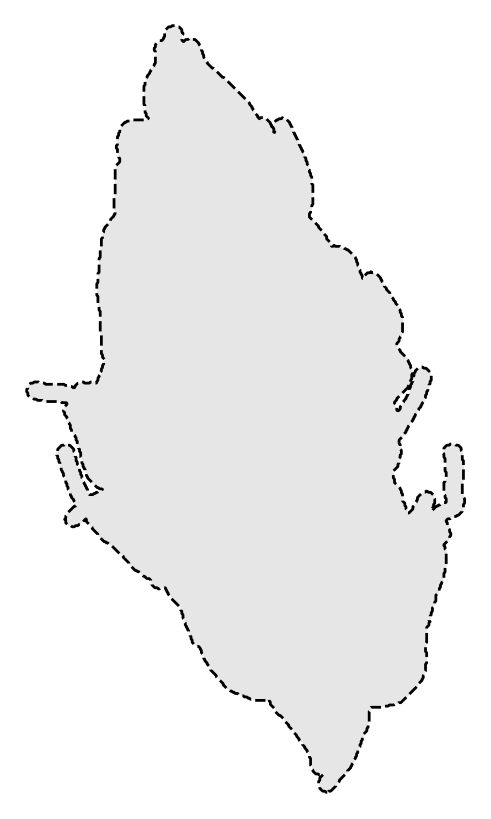

In [6]:
from skimage import measure
fig,ax = plt.subplots(figsize=(8,8))
contours = measure.find_contours(retrieve_mask(ResultsDF.loc[0]['Mask Filled'],ResultsDF.loc[0]['Image Size']), level=0.5)
ax.imshow(1-retrieve_mask(ResultsDF.loc[0]['Mask Filled'],ResultsDF.loc[0]['Image Size']),cmap='gray',alpha=0.1)
for contour in contours:
    ax.plot(contour[:, 1], contour[:, 0], '--',color='black', linewidth=2)  # (y, x)
x_,y_  = ResultsDF.loc[0]['Mask Filled']
ax.set_ylim([max(x_)+15,min(x_)-15]) # different axes
ax.set_xlim([min(y_)-15,max(y_)+15]) # different axes
ax.axis('off')
fig.tight_layout(pad=0)
plt.savefig(os.path.join(str(sfolder),"hpacell_maskfilled.pdf"),format='pdf',transparent=True,bbox_inches='tight')
plt.savefig(os.path.join(str(sfolder),"hpacell_maskfilled.png"),format='png',transparent=True,bbox_inches='tight',dpi=1200)

In [10]:
ResultsDF.loc[0][['DCF:Centroid','DNF:Centroid','Nucleus Centroid']]

DCF:Centroid          [29.402, 16.05]
DNF:Centroid         [29.185, 15.171]
Nucleus Centroid    (525.09, 189.429)
Name: 0, dtype: object

In [7]:
def centroid_distance(row, key1="DCF:Centroid", key2="DNF:Centroid"):
    p1 = np.array(row[key1], dtype=float)
    p2 = np.array(row[key2], dtype=float)
    return np.linalg.norm(p1 - p2)

# Example on the first row
d = centroid_distance(ResultsDF.loc[0])
print(d)

0.9053894189794817


<div class="alert alert-block alert-info">
    
 **INSTRUCTIONS**
    
</div>

**1.** Import a dataframe with results.

**2.** You can either analyze

- **OPTION 1:** select a specific cell from the dataframe 

- **OPTION 2:** and/or the whole dataset of cells (global analysis)

<div class="alert alert-block alert-info">
    
 **SELECT CELL**
    
</div>

In [8]:
def dropdown_cell_eventhandler(change):
    global cell
    cell = dropdown_image.value
    lab = ResultsDF.loc[cell]['Label']
    print('Cell ' + str(cell) + ' (' + str(lab) +') selected.')

dropdown_image = widgets.Dropdown(description =  'Select Cell:' , options = ['...'] + list(ResultsDF.index))
dropdown_image.observe(dropdown_cell_eventhandler, names='value')
display(dropdown_image)

Dropdown(description='Select Cell:', options=('...', 0), value='...')

Cell 0 (Cells) selected.


<div class="alert alert-block alert-info">
    
 **PLOT INTENSITY**
    
</div>

In [19]:
data['CYTO_PRE'].loc['HPA']['Texture']

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
retrieve_mask()

In [11]:
ResultsDF.columns

Index(['Path', 'Name', 'Img Index', 'Label', 'Image Size', 'Resolution',
       'Mask', 'Mask Filled', 'Skeleton', 'Patch:Deconvoluted Cyto',
       'Patch:Cyto Mask', 'Patch:Skeleton', 'Offset', 'Lines', 'DCF:Area',
       'DCF:Area convex', 'DCF:BB Area', 'DCF:Perimeter', 'DCF:Centroid',
       'DCF:Weighted Centroid', 'DCF:Centroid Divergence',
       'DCF:Equivalent Diameter', 'DCF:Extent', 'DCF:Major Axis Length',
       'DCF:Minor Axis Length', 'DCF:Euler Number', 'DCF:Eccentricity',
       'DCF:Circularity', 'DCF:Roundness', 'DCF:Orientation', 'DCF:Solidity',
       'DCF:Roughness', 'DCF:Crofton Perimeter', 'DCF:Mean Intensity',
       'DCF:Std', 'DCF:Variance', 'DCF:Skewness', 'DCF:Kurtosis',
       'DCF:Contrast', 'DCF:Max Intensity', 'DCF:Min Intensity', 'DCF:Entropy',
       'DCF:Inertia Tensor Highest Eigenvalue',
       'DCF:Inertia Tensor Lowest Eigenvalue', 'DCF:Uniformity',
       'DCF:Invariant Uniformity', 'DCF:GLCM Entropy',
       'DCF:GLCM Invariant Entropy', 'DCF:

In [9]:
ResultsDF['DCF:Mean Intensity']

0    0.123012
Name: DCF:Mean Intensity, dtype: object

In [213]:
def plot_soax_filaments(ResultsRow, data, save):
    import matplotlib.pyplot as plt
    import numpy as np

    filament_df = data['filaments']
    junctionsdf = data['junctions']
    
    img = data['CYTO']['Image'][str(ResultsRow['Img Index'])] / np.max(data['CYTO']['Image'][str(ResultsRow['Img Index'])])
    imgorig = retrieve_mask(ResultsRow['Mask'], ResultsRow['Image Size']) * img
    
    skel = retrieve_mask(ResultsRow['Skeleton'], ResultsRow['Image Size'])
    
    fig, ax = plt.subplots(figsize=(8, 8))
    fig2, ax2 = plt.subplots(figsize=(12, 12))
    fig3, ax3 = plt.subplots(figsize=(8, 8))
    fig4, ax4 = plt.subplots(figsize=(8, 8))
    fig5, ax5 = plt.subplots(figsize=(8, 8))
    fig6, ax6 = plt.subplots(figsize=(8, 8))   # new
    
    ax.imshow(np.max(skel) - skel, cmap='gray', alpha=1, zorder=1)
    ax5.imshow(1 - np.zeros_like(skel), cmap='gray', alpha=0, zorder=1)
    ax2.imshow(np.max(imgorig) - imgorig, cmap='gray')
    ax6.imshow(np.max(imgorig) - imgorig, cmap='gray')   # new
    
    mask = data['CYTO_PRE'].loc['HPA']['Texture']
    int_only_fils = mask * img
    ax3.imshow(np.max(int_only_fils) - int_only_fils, cmap='gray')
    ax4.imshow(np.max(mask) - mask, cmap='gray')
    
    zorder = 2
    # PLOT FILAMENT
    for filament in filament_df:
        x = [float(a) for a in filament['x']] 
        y = [float(b) for b in filament['y']]
        
        ax.plot(x, y, linewidth=0.5, zorder=zorder)
        ax2.plot(x, y, linewidth=1, alpha=0.4, zorder=zorder)
        ax5.plot(x, y, linewidth=1.2, zorder=zorder)
        zorder += 1
        
    ax.axis('off')
    ax2.axis('off')
    ax3.axis('off')
    ax4.axis('off')
    ax5.axis('off')
    ax6.axis('off')
    
    # PLOT JUNCTION
    for index, row in junctionsdf.iterrows():
        ax.plot(row[0], row[1], 'ko', zorder=200, markersize=3)
        ax2.plot(row[0], row[1], 'ko', zorder=300, markersize=2, alpha=0.4)
        ax5.plot(row[0], row[1], 'ko', zorder=300, markersize=4)
    
    if 'NUCL' in data.keys():
        if 'Nucleus Centroid' in ResultsRow.keys():
            ax.plot(ResultsRow['Nucleus Centroid'][1], ResultsRow['Nucleus Centroid'][0], '.', color='#6495ED', markersize=5, zorder=200)
            ax6.plot(ResultsRow['Nucleus Centroid'][1], ResultsRow['Nucleus Centroid'][0], '.', color='#6495ED', markersize=5, zorder=200)   # new
        if 'Nucleus Contour' in ResultsRow.keys():
            ax.plot(ResultsRow['Nucleus Contour'][:, 0], ResultsRow['Nucleus Contour'][:, 1], '--', color='#6495ED', zorder=200, linewidth=2.5, alpha=0.5)
            ax6.plot(ResultsRow['Nucleus Contour'][:, 0], ResultsRow['Nucleus Contour'][:, 1], '--', color='#6495ED', zorder=200, linewidth=2.5, alpha=0.5)   # new

    plt.tight_layout(pad=0)
    
    # CROP
    x_, y_ = ResultsRow['Mask']
    ax.set_ylim([max(x_), min(x_)])
    ax.set_xlim([min(y_), max(y_)])
    ax2.set_ylim([max(x_), min(x_)])
    ax2.set_xlim([min(y_), max(y_)])
    ax3.set_ylim([max(x_), min(x_)])
    ax3.set_xlim([min(y_), max(y_)])
    ax4.set_ylim([max(x_), min(x_)])
    ax4.set_xlim([min(y_), max(y_)])
    ax5.set_ylim([max(x_), min(x_)])
    ax5.set_xlim([min(y_), max(y_)])
    ax6.set_ylim([max(x_), min(x_)])   # new
    ax6.set_xlim([min(y_), max(y_)])   # new

    if save:
        #fig.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig2\\" + str("skelsoax") + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
        #fig2.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig2\\" + str("origsoax") + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
        #fig3.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig2\\" + str("int_only_fils") + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
        #fig4.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig2\\" + str("only_mask") + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
        #fig2.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig3_new\\" + str("only_filaments") + ".pdf", format='pdf', transparent=True, bbox_inches='tight')
        fig6.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig3_new\\" + str("original_nuclboundary_graphabst") + ".pdf", format='pdf', transparent=True, bbox_inches='tight')  # new
    
    plt.show()
    
    return fig, fig2, fig6

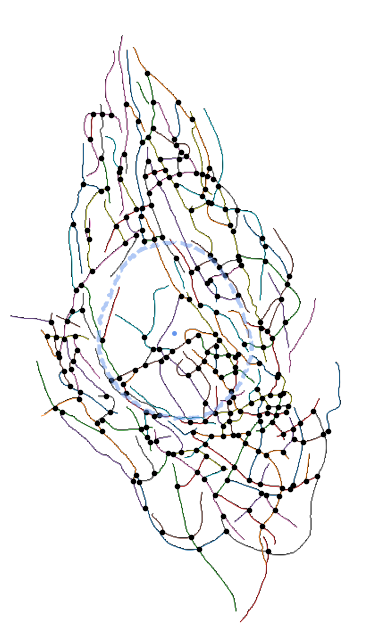

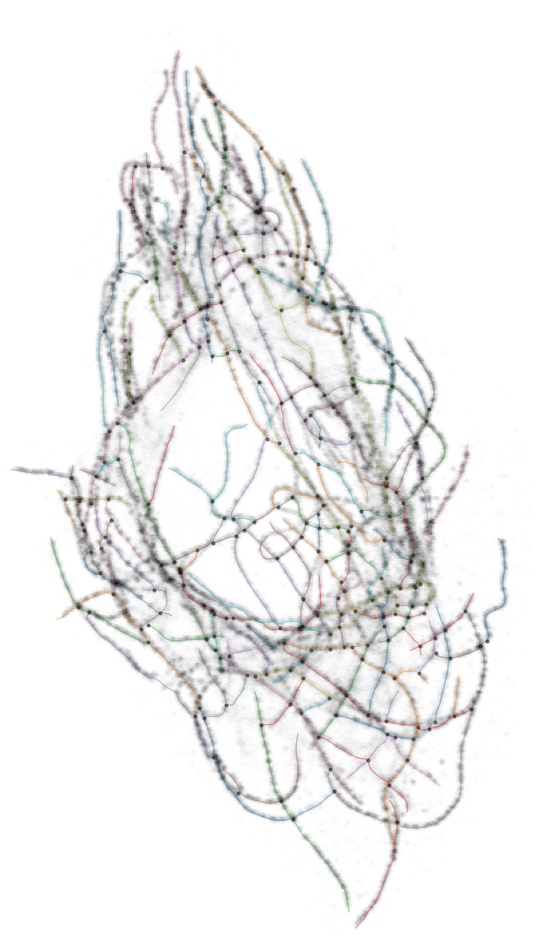

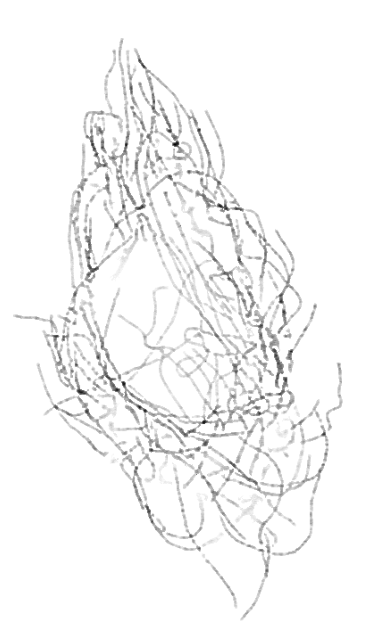

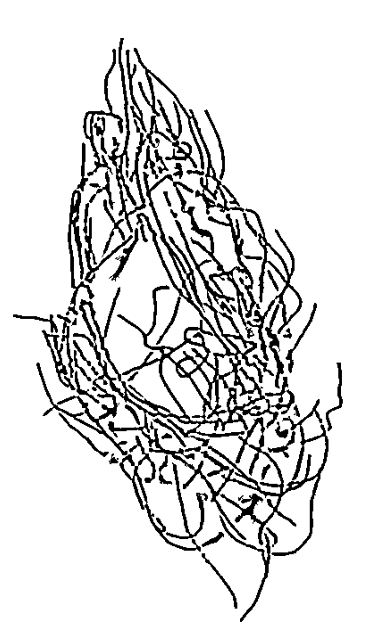

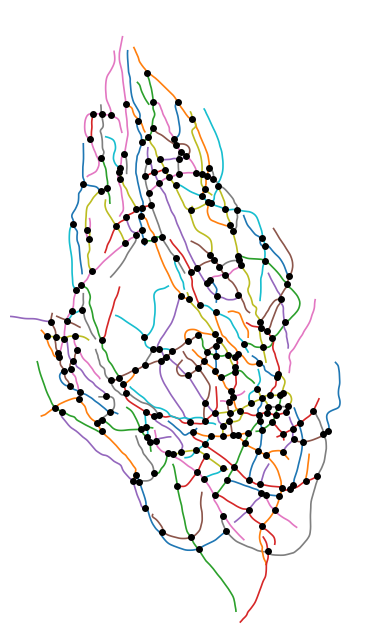

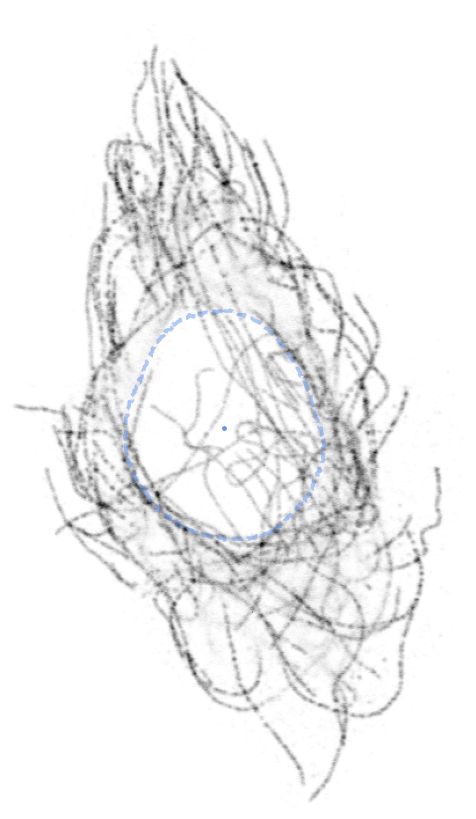

ValueError: too many values to unpack (expected 2)

In [214]:
fig1,fig2 = plot_soax_filaments(ResultsRow = ResultsDF.loc[cell],
                                data       = data,
                                save       = True)
                               

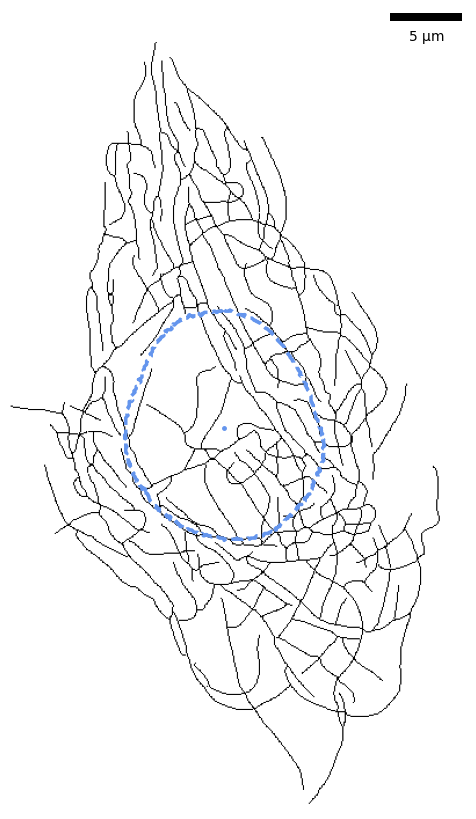

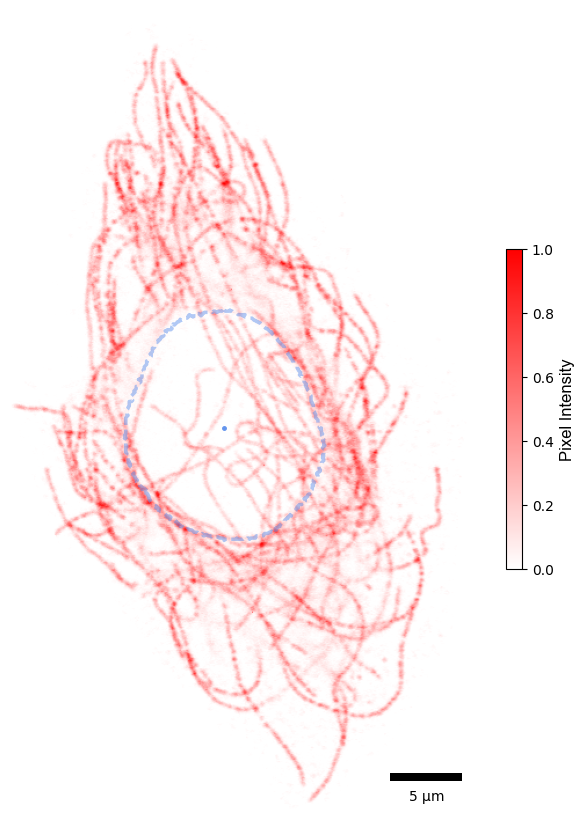

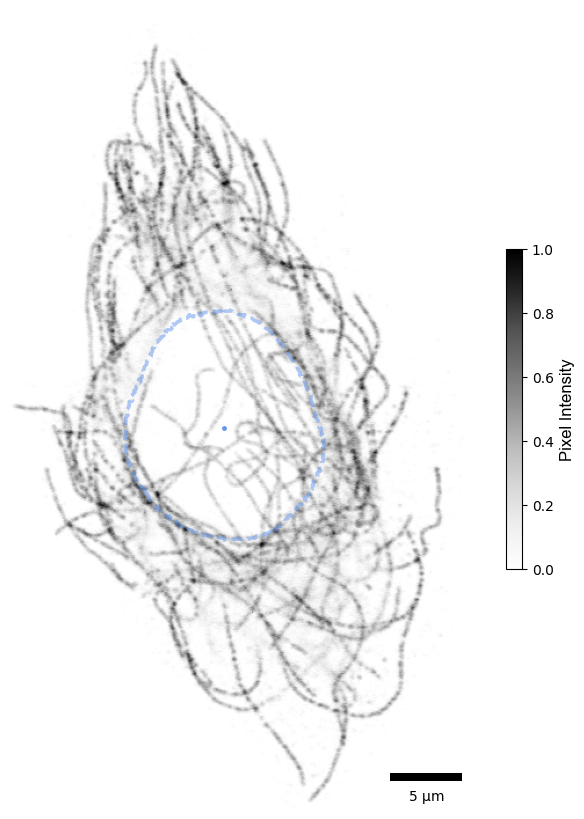

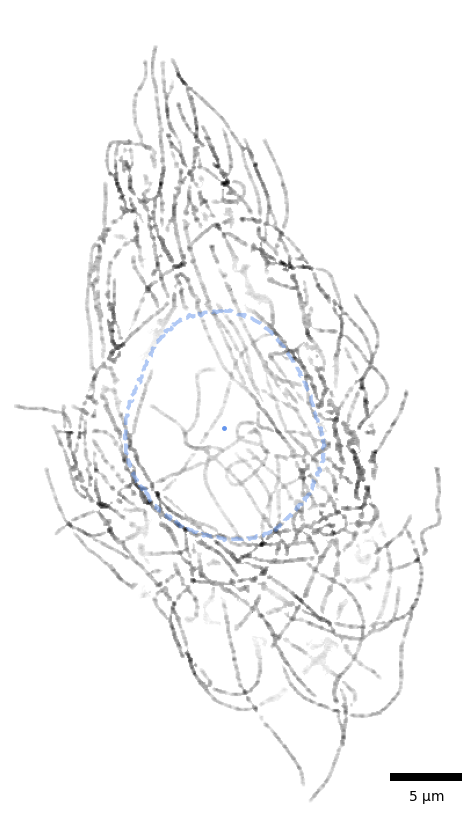

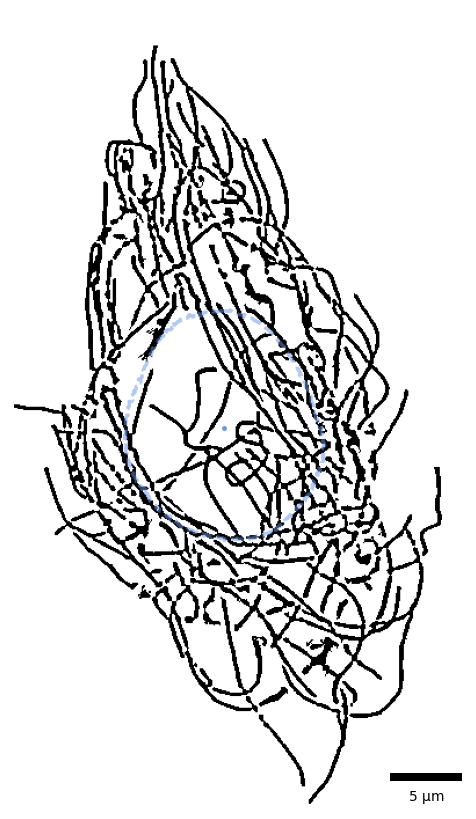

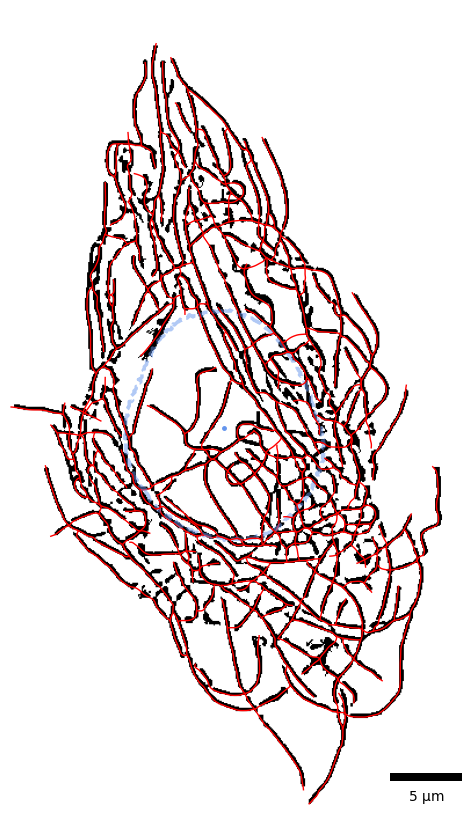

In [8]:
fig_int = intensity_plotter(ResultsRow = ResultsDF.loc[cell],
                                  data       = data,
                                  nucl       = False
                                  save       = os.path.join(sfolder,'hpacellx'))   

In [32]:
def plot_histogram(ResultsRow, data, units, feat, bins, save):
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    from brokenaxes import brokenaxes
    import os

    # --- added: font settings ---
    label_fontsize = 14
    tick_fontsize = 14
    fontname = "Arial"
    # ----------------------------

    if feat == "Pixel Intensity":
        try:
            image = data['CYTO']['Image'][str(ResultsRow['Img Index'])]
            image = image / np.max(image)
            
            mask = data['CYTO_PRE'].loc['HPA']['Texture']
            image = mask * image
        except:
            print('errror: review code')
            image = data['CYTO']['Image'][ResultsRow['Img Index']]
            image = image / np.max(image)
        mask = retrieve_mask(ResultsRow['Mask'], ResultsRow['Image Size'])
        feat_list = image[mask.astype(bool)].flatten()
        feat_list = feat_list[feat_list > 0]
        
        # EASY FIX
        print(np.mean(feat_list), np.std(feat_list), np.std(feat_list) / np.mean(feat_list))
        
        
        def compute_AMI(feat_list, pixel_size_um=1.0):
            """
            AMI = average intensity per µm² over the selected region.
            feat_list: iterable of pixel intensities (e.g., 0–255 or 0–1)
            pixel_size_um: pixel size in micrometers (isotropic XY)
            """
            arr = np.asarray(feat_list, dtype=float)
            if arr.size == 0:
                return 0.0
            return float(arr.mean()) / (pixel_size_um**2)
    
        print('ami:', compute_AMI(feat_list, 0.08))
        print('total int:', np.sum(feat_list))
        
    else:
        feat_list = np.array(ResultsRow[feat])

    # Calculate histogram
    hist_values, bin_edges = np.histogram(feat_list, bins=bins)

    # Normalize colormap
    norm = mcolors.Normalize(vmin=np.min(feat_list), vmax=np.max(feat_list))
    colormap = cm.Greys if feat == "Pixel Intensity" else cm.rainbow
    colors = colormap(norm(bin_edges[:-1]))

    # Use brokenaxes if needed
    use_broken_axis = (
        len(hist_values) > 1
        and hist_values[0] > 5 * np.max(hist_values[1:])
    )

    xlabel_text = f"{feat.split(':')[-1] if ':' in feat else feat} ({units})"

    if use_broken_axis:
        # Define break: keep low values and break before tall bar
        ylims = ((0, np.max(hist_values[1:]) * 1.2), (hist_values[0] * 0.95, hist_values[0] * 1.05))
        fig_hist = plt.figure(figsize=(4, 4))
        bax = brokenaxes(ylims=ylims, hspace=0.05, despine=False, fig=fig_hist)
        bax.bar(
            bin_edges[:-1], hist_values, width=np.diff(bin_edges),
            color=colors, edgecolor="black", linewidth=2, alpha=1
        )
        bax.set_xlabel(xlabel_text, fontsize=label_fontsize, fontname=fontname)

        # set tick font on both broken axes
        for ax in bax.axs:
            ax.tick_params(axis='both', labelsize=tick_fontsize)
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontname(fontname)

        fig_hist = bax.fig
    else:
        fig_hist, ax_hist = plt.subplots(figsize=(4, 4))
        ax_hist.bar(
            bin_edges[:-1],
            hist_values,
            width=np.diff(bin_edges),
            color=colors,
            edgecolor="black",
            linewidth=2,
            alpha=1,
            label=feat.split(":")[-1] if ":" in feat else feat,
        )
        ax_hist.set_xlabel(xlabel_text, fontsize=label_fontsize, fontname=fontname)
        ax_hist.set_ylabel("Absolute Frequency", fontsize=label_fontsize, fontname=fontname)
        #ax_hist.set_ylabel("Pixel Counts", fontsize=label_fontsize, fontname=fontname)
        ax_hist.tick_params(axis='both', labelsize=tick_fontsize)

        for label in ax_hist.get_xticklabels() + ax_hist.get_yticklabels():
            label.set_fontname(fontname)

    if save:
        plt.savefig(str(save) + ".pdf", format='pdf', transparent=True, bbox_inches='tight')

    plt.show()

0.26116490434904494 0.13432683432368195 0.5143372332453795
ami: 40.807016304538266
total int: 10022.2032043946


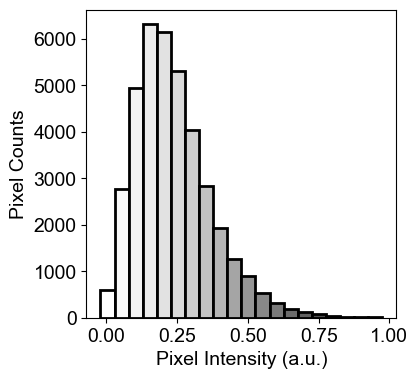

In [31]:
plot_histogram(ResultsRow = ResultsDF.loc[0],
                    data  = data,
                    feat  = "Pixel Intensity",
                    units = "a.u.",
                    bins  = 20,
                    save  = os.path.join(sfolder,"hist_intensities"))

<div class="alert alert-block alert-info">
    
 **PLOT LINES**
    
</div>

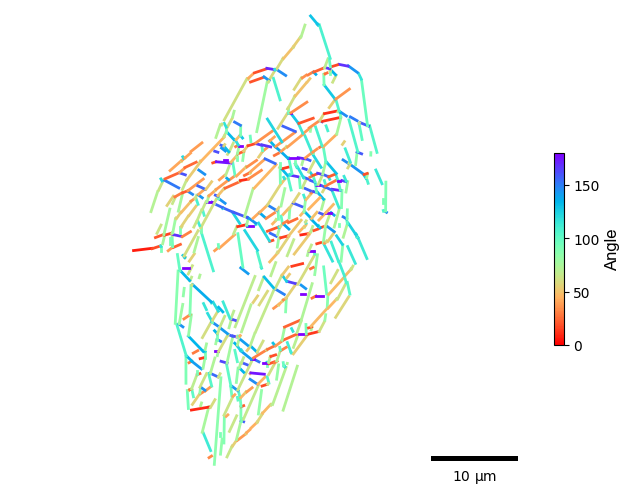

In [6]:
# PLOT LINES
%matplotlib inline

cmap     = pltc.rainbow_r
cm       = truncate_colormap(cmap, 0, 1, 300)

# ORIENTATION
fig_lines = line_plotter(ResultsRow = ResultsDF.loc[cell],
             data=data,
             feat='LSF2D:Theta',
             cmap=cm,
             normalize_bounds=[0, 180],
             colorbar_label='Angle',
             overlay=False,
             save=False)

# BUNDLING
# line_plotter(ResultsRow = ResultsDF.loc[cell],
#              data=data,
#              feat="LSF2D:Local Line Distance (LinReg)",
#              cmap=cm,
#              normalize_bounds=[0,4],
#              colorbar_label='Local Line Distance (µ)',
#              line_data_origin = 'Lines LinReg',
#              overlay=False,
#              save='bundling_lines0')

# PARALLELISM
# line_plotter(ResultsRow = ResultsDF.loc[cell],
#              data=data,
#              feat="LSF2D:Angle Difference (LinReg)",
#              cmap=cm,
#              normalize_bounds=[0,90],
#              colorbar_label='Mean Angle Difference (º)',
#              line_data_origin = 'Lines LinReg',
#              overlay=False,
#              save='parallelism_lines2')

# COMPACTNESS & QUANTITY
# line_plotter(ResultsRow = ResultsDF.loc[cell],
#              data=data,
#              feat=None,
#              cmap=cm,
#              normalize_bounds=None,
#              colorbar_label=None,
#              line_data_origin = 'Lines LinReg',
#              overlay=False,
#              save='compactness_lines1')

# RADIALITY
# line_plotter(ResultsRow = ResultsDF.loc[cell],
#              data=data,
#              feat="LSF2D:Alphas (LinReg)",
#              cmap=cm,
#              normalize_bounds=[0,90],
#              colorbar_label='Angle (º)',
#              line_data_origin = 'Lines LinReg',
#              overlay=False,
#              save=False)

# CYTO-NUC INTERACTION
# line_plotter(ResultsRow = ResultsDF.loc[cell],
#              data=data,
#              feat="LSF2D:Distances to Centroid (LinReg) (scaled)",
#              cmap=cm,
#              normalize_bounds=[0,30],
#              colorbar_label='Distance (μm)',
#              line_data_origin = 'Lines LinReg',
#              overlay=False,
#              save='cytonuc_lines0')

<div class="alert alert-block alert-info">
    
 **PLOT GRAPH**
    
</div>

KeyError: 'SKNW:branch-distance'

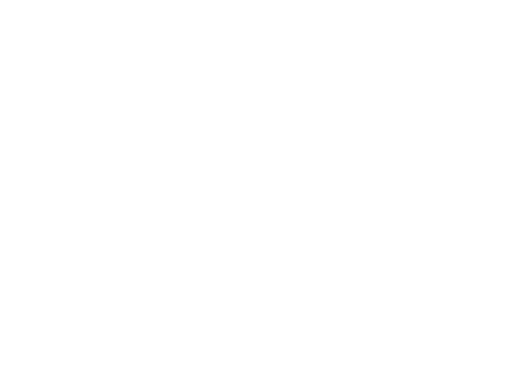

In [7]:
cmap     = pltc.rainbow
cm       = truncate_colormap(cmap, 0, 1, 300)

fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[cell],
                          data             = data,
                          feat             = 'SKNW:branch-distance',
                          cmap             = cm,
                          normalize_bounds = [0,6],
                          colorbar_label   = 'Length (μm)',
                          nodes            = True,
                          main_branch      = False,
                          overlay          = None,
                          scalebar         = True,
                          save             = 'morphology_graph_fig4c')

# graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'CNF2D:Branch Orientation',
#               cmap             = cm,
#               normalize_bounds = [0,180],
#               colorbar_label   = 'Angle (º)',
#               nodes            = True,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = False)

# graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'CNF2D:Local Average Branch Distance',
#               cmap             = cm,
#               normalize_bounds = 'default',
#               colorbar_label   = 'Distance (μm)',
#               nodes            = False,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = False)

# graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'CNF2D:Mean Filament Thickness',
#               cmap             = cm,
#               normalize_bounds = [1,2],
#               colorbar_label   = 'Thickness (μm)',
#               nodes            = False,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = False)

# graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'CNF2D:Local Average Branch Orientation',
#               cmap             = cm,
#               normalize_bounds = 'default',
#               colorbar_label   = 'Angle (º)',
#               nodes            = False,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = False)

# graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'CNF2D:Local Average Bundling Score',
#               cmap             = cm,
#               normalize_bounds = 'default',
#               colorbar_label   = 'Distance * Angle (umº)',
#               nodes            = False,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = False)

# fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#                           data             = data,
#                           feat             = 'CNF2D:Distances to Centroid',
#                           cmap             = cm,
#                           normalize_bounds = 'default',
#                           colorbar_label   = 'Distance (μm)',
#                           nodes            = False,
#                           main_branch      = False,
#                           overlay          = None,
#                           scalebar         = True,
#                           save             = False)

# fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               cmap             = cm,
#               feat             = None,
#               normalize_bounds = 'default',
#               colorbar_label   = None,
#               nodes            = True,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = 'figure4_graph')

# fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'branch-type',
#               cmap             = cm,
#               normalize_bounds = 'default',
#               colorbar_label   = None,
#               nodes            = True,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = 'connectivity2')

#graph_plotter(ResultsRow=ResultsDF.loc[cell],data=data,feat=None,cmap=cm,normalize_bounds='default',colorbar_label=None,nodes=True,main_branch=False, overlay = None,scalebar=False, save='preprocessing_cellX_paper_graph')

<div class="alert alert-block alert-info">
    
 **PLOT SOAX**
    
</div>

In [107]:
def plot_soax(ResultsRow, data, feat=None, nodes=False, colorbar_label=None, bounds='default', overlay=None, scalebar=True, save=False):
    
    filaments_df = data['filaments']
    junctions_df = data['junctions']
    
    img = data['CYTO']['Image'][str(ResultsRow['Img Index'])] / np.max(data['CYTO']['Image'][str(ResultsRow['Img Index'])])
    imgorig = retrieve_mask(ResultsRow['Mask'], ResultsRow['Image Size']) * img
    
    skel = retrieve_mask(ResultsRow['Skeleton'], ResultsRow['Image Size'])
    
    if feat is None:
        feat_list = np.arange(len(filaments_df))
        cmap = pltc.get_cmap('rainbow')
        color_values = np.linspace(0, 1, len(filaments_df))
        np.random.seed(20)
        np.random.shuffle(color_values)
        shuffled_colors = cmap(color_values)
        
    if isinstance(feat, str):
        feat_list = ResultsRow[feat]
        
    if isinstance(feat_list, list) and isinstance(feat_list[0], (list, np.ndarray)):
        feat_list = ResultsRow[feat]
        cmap = pltc.get_cmap('rainbow')
        color_values = np.linspace(0, 1, len(filaments_df))
        np.random.seed(20)
        np.random.shuffle(color_values)
        shuffled_colors = cmap(color_values)
    
    cmap = pltc.rainbow
    if feat == 'CNF2D:Branch Orientations':
        cmap = pltc.rainbow
    if feat == 'CNF2D:Branch Curvatures':
        cmap = pltc.rainbow
    cm = truncate_colormap(cmap, 0, 1, 300)
    
    if feat == 'CNF2D:Branch Orientations':
        normalize_bounds = [0, 180]
    elif bounds == 'default':
        if isinstance(feat_list, list) and isinstance(feat_list[0], (list, np.ndarray)):
            all_values = np.concatenate([np.array(f) for f in feat_list])
            normalize_bounds = [0, np.max(all_values)]
        else:
            normalize_bounds = [0, np.max(feat_list)]
    else:
        normalize_bounds = bounds
        
    fig, ax = plt.subplots(figsize=(5, 5))
    
    zorder = 2
    
    i = 0
    for filament in filaments_df:
        x = [float(a) for a in filament['x']] 
        y = [float(b) for b in filament['y']]
        
        if feat is None:
            colour = shuffled_colors[i]
        elif feat == 'CNF2D:Branch Connectivity Type':
            color_map = {0: 'red', 1: 'orange', 2: 'green'}
            colour = color_map.get(feat_list[i], 'gray')
        elif feat == 'CNF2D:Branch Orientations':
            angle = 180 - feat_list[i]
            colour = circular_rainbow_colormap()(angle / 180.0)
        else:
            colour = cmap(plt.Normalize(normalize_bounds[0], normalize_bounds[1])(feat_list[i]))
        
        if isinstance(feat_list, list) and isinstance(feat_list[i], (list, np.ndarray)):
            values_2d = np.array(feat_list[i])
            norm = plt.Normalize(normalize_bounds[0], normalize_bounds[1])

            base_rgb = shuffled_colors[i][:3]
            
            for j in range(len(x) - 1):
                alpha = np.clip(norm(values_2d[j]) ** 0.7, 0, 1)
                rgba = (*base_rgb, alpha)
                ax.plot(x[j:j+2], y[j:j+2], linewidth=1.5, color=rgba, zorder=zorder)
        else:
            ax.plot(x, y, linewidth=1.5, color=colour, zorder=zorder)
        
        zorder += 1
        i += 1
    
    ax.axis('off')
    ax.axis('equal')
    
    if nodes:
        for index, row in junctions_df.iterrows():
            ax.plot(row[0], row[1], 'ko', zorder=300, markersize=2)
    
    if feat == 'CNF2D:Branch Connectivity Type':
        from matplotlib.patches import Patch
        color_map = {0: 'red', 1: 'orange', 2: 'green'}
        handles = [Patch(color=color_map[k], label=f'{k} ({"free" if k==0 else "connected" if k==2 else "semi"})') for k in sorted(color_map)]
        ax.legend(handles=handles, title='Connectivity Type', loc='lower right', frameon=False, fontsize=8)
    else:
        cbar = fig.colorbar(
            pltc.ScalarMappable(norm=plt.Normalize(normalize_bounds[0], normalize_bounds[1]), cmap=cmap),
            ax=ax,
            shrink=0.4
        )
        cbar.set_label(colorbar_label, fontfamily='arial', fontsize=10)
    
    if scalebar == True:
        scalebar = ScaleBar(ResultsRow['Resolution'][1], "um", color='k', box_alpha=0, dimension='si-length') 
        ax.add_artist(scalebar)
    
    fig.tight_layout(pad=0)
    
    x_, y_ = ResultsRow['Mask']
    ax.set_ylim([max(x_), min(x_)])
    ax.set_xlim([min(y_), max(y_)])
    
    if save != False:
        plt.savefig(str(save) + ".pdf", format='pdf', transparent=True, bbox_inches='tight')
    fig.show()

    return fig

### QUANTITY & INDIVIDUAL FILAMENTS

C:\Users\diogo\AppData\Local\Temp\ipykernel_31244\2379284878.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


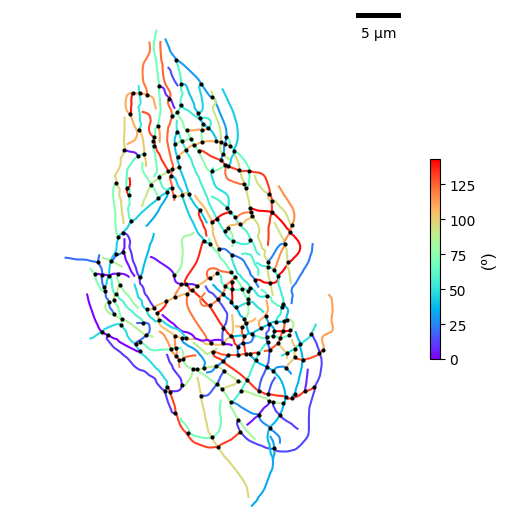

In [24]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = None,
                     nodes               = True,
                     colorbar_label      = '(º)',
                     bounds              = 'default',
                     overlay             = None, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"original"))

In [6]:
ResultsDF.loc[0]['CNF1D:Number of Branches']

144

In [7]:
ResultsDF.loc[0]['DCF:Mean Intensity']

0.12301191860975119

### BUNDLING: THICKNESS

C:\Users\diogo\AppData\Local\Temp\ipykernel_18484\3016632810.py:155: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


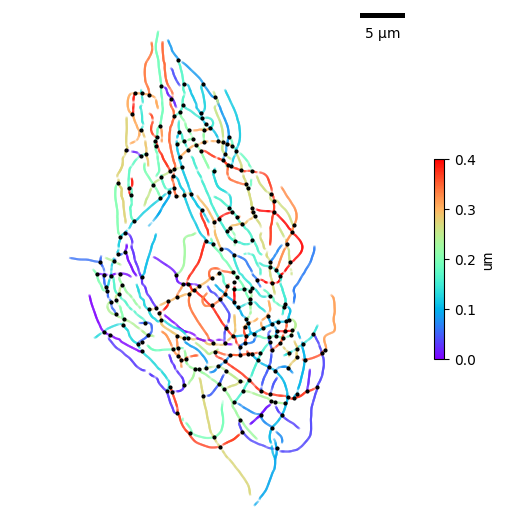

In [6]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF3D:Branch Thicknesses',
                     nodes               = True,
                     colorbar_label      = 'um',
                     bounds              = 'default',
                     overlay             = True, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"thicknesses"))

C:\Users\diogo\AppData\Local\Temp\ipykernel_2160\3435091962.py:117: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


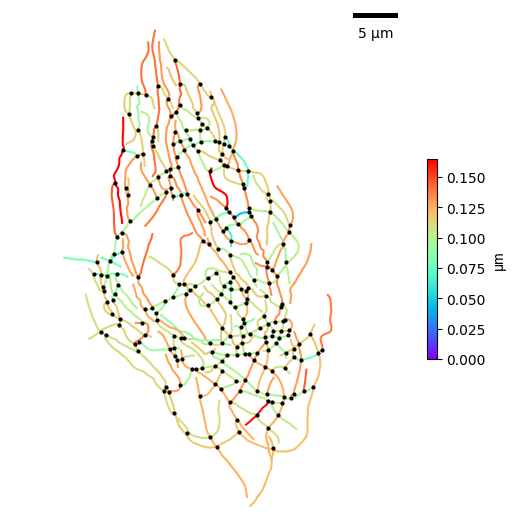

In [100]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF2D:Branch Thicknesses',
                     nodes               = True,
                     colorbar_label      = 'μm',
                     bounds              = 'default',
                     overlay             = None, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"mthicknesses"))

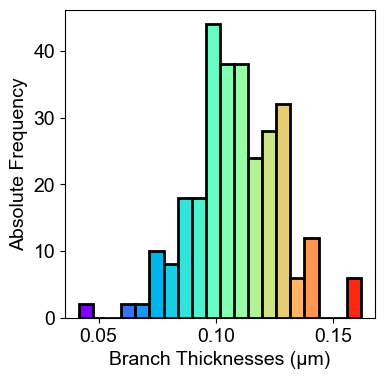

In [99]:
plot_histogram(ResultsRow = ResultsDF.loc[0],
                    data  = data,
                    feat  = "CNF2D:Branch Thicknesses",
                    units = "μm",
                    bins  = 20,
                    save  = os.path.join(sfolder,"hist_thicknesses"))

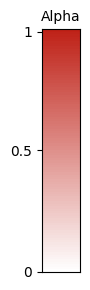

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(1, 3))

# Alpha values
n = 100
alphas = np.linspace(0, 1, n)

# Red from image
base_color = (0.75, 0.13, 0.09)

for i, alpha in enumerate(alphas):
    ax.add_patch(Rectangle((0, i), 1, 1, color=(*base_color, alpha), linewidth=0))

# Formatting
ax.set_xlim(0, 1)
ax.set_ylim(0, n)
ax.set_xticks([])
ax.set_yticks([0, n//2, n-1])
ax.set_yticklabels(['0', '0.5', '1'])
ax.set_title('Alpha', fontsize=10)
plt.tight_layout()
plt.savefig(str(os.path.join(sfolder,"alphacurv_bar")) + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
plt.show()


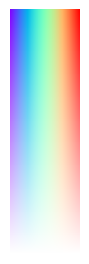

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# Dimensions
width, height = 100, 350

# Create horizontal gradient of color (rainbow colormap)
x = np.linspace(0, 1, width)
cmap = cm.get_cmap('rainbow')
colors = cmap(x)

# Create vertical gradient of alpha (1 at top, 0 at bottom)
alpha = np.linspace(1, 0, height).reshape(-1, 1)

# Tile colors across height and apply alpha
img = np.tile(colors, (height, 1, 1))
img[:, :, 3] = alpha  # Set alpha channel

# Plot
fig, ax = plt.subplots(figsize=(1, 3))
ax.imshow(img, origin='upper')
ax.axis('off')
plt.tight_layout()
plt.show()


C:\Users\diogo\AppData\Local\Temp\ipykernel_2160\1534547823.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(Rectangle((j, height - 1 - i), 1, 1, color=(*color, 1-alpha), linewidth=0.1, edgecolor='black'))


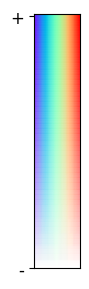

In [101]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import os

# Parameters
width = 100
height = 150
cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0, 1, width))
#save_path = "alpharainbow_bar.pdf"

fig, ax = plt.subplots(figsize=(1, 3))

# Plot rectangles row by row
for i in range(height):
    alpha = i / (height - 1)  # alpha = 0 (top) → 1 (bottom), invert for desired effect
    for j in range(width):
        color = colors[j][:3]
        ax.add_patch(Rectangle((j, height - 1 - i), 1, 1, color=(*color, 1-alpha), linewidth=0.1, edgecolor='black'))

# Border lines (right and top)
ax.plot([0, width], [height, height], color='black', linewidth=0.6)  # top
ax.plot([width, width], [0, height], color='black', linewidth=0.6)   # right

# Formatting
ax.set_xlim(0, width)
ax.set_ylim(0, height)
ax.set_xticks([])
ax.set_yticks([0,  height - 1])
ax.set_yticklabels(['-',  '+'],fontsize=12)
#ax.set_title('Alpha', fontsize=10)

plt.tight_layout()
plt.savefig(str(os.path.join(sfolder,"alphacurv_bar")) + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
plt.show()


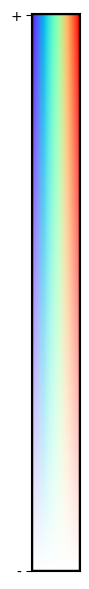

In [102]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import os

# Parameters
height = 400
width = 50
cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0, 1, width))

fig, ax = plt.subplots(figsize=(1, 6))

# Plot rectangles: top (low alpha) to bottom (high alpha)
for i in range(height):
    alpha = (i / (height - 1))  # alpha goes 1 → 0 from top to bottom
    for j in range(width):
        rgb = colors[j][:3]
        ax.add_patch(Rectangle((j, i), 1, 1, color=(*rgb, alpha), linewidth=0))

# Border lines
ax.plot([0, width], [height, height], color='black', linewidth=2.5)  # top
ax.plot([width, width], [0, height], color='black', linewidth=2.5)   # right
ax.plot([0, 0], [0, height], color='black', linewidth=2.5)      # left
ax.plot([0, width], [0, 0], color='black', linewidth=2.5)       # bottom

# Formatting
ax.set_xlim(0, width)
ax.set_ylim(0, height)
ax.set_xticks([])
ax.set_yticks([0, height - 1])
ax.set_yticklabels(['-', '+'])

plt.tight_layout()

# Save path
#save_path = os.path.join(sfolder, "alphacurv_bar_fixed.pdf")
plt.savefig(str(os.path.join(sfolder,"alphacurv_bar")) + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
plt.show()


In [11]:
FULL['CNF1D:Branch Thicknesses mean'],FULL['CNF1D:Branch Thicknesses std_dev']

(0    0.111872
 Name: CNF1D:Branch Thicknesses mean, dtype: float64,
 0    0.018988
 Name: CNF1D:Branch Thicknesses std_dev, dtype: float64)

### BUNDLING: LOCAL ANGLES

C:\Users\diogo\AppData\Local\Temp\ipykernel_2160\3435091962.py:117: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


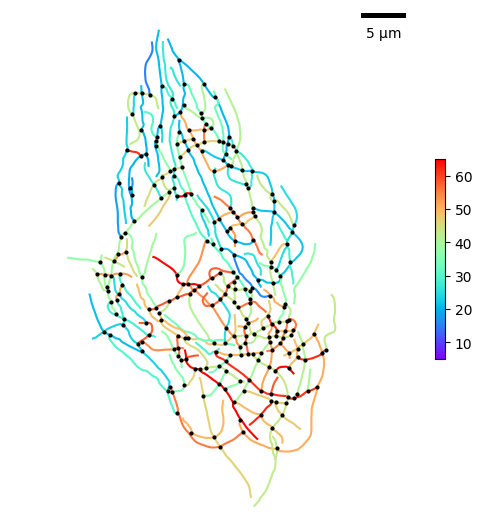

In [98]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF2D:Local Average Bundling Score',
                     nodes               = True,
                     colorbar_label      = '',
                     bounds              = [5,65],
                     overlay             = None, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"bundlescore"))

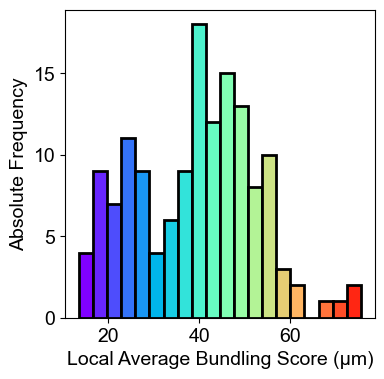

In [97]:
plot_histogram(ResultsRow = ResultsDF.loc[0],
                    data  = data,
                    feat  = "CNF2D:Local Average Bundling Score",
                    units = "μm",
                    bins  = 20,
                    save  = os.path.join(sfolder,"hist_bundlescore"))

In [103]:
ResultsDF.loc[0]['DCF:Skewness']

1.4745429695038144

In [104]:
ResultsDF.loc[0]['DCF:Std'] / ResultsDF.loc[0]['DCF:Mean Intensity']

1.080364120260223

In [22]:
np.mean(ResultsDF.loc[0]['CNF2D:Branch Lengths']),np.std(ResultsDF.loc[0]['CNF2D:Branch Lengths'])

(6.220788543309892, 4.187909639117828)

In [23]:
np.std(ResultsDF.loc[0]['CNF2D:Branch Lengths']) / np.mean(ResultsDF.loc[0]['CNF2D:Branch Lengths'])

0.6732120228747671

In [75]:
np.mean(ResultsDF.loc[0]['CNF2D:Branch Menger Curvatures']),np.std(ResultsDF.loc[0]['CNF2D:Branch Menger Curvatures'])

(0.5055045599116454, 0.5083571643496361)

In [69]:
0.491*228

111.948

In [70]:
0.39*228

88.92

In [71]:
0.118*228

26.904

In [73]:
27+89+112

228

In [19]:
FULL.columns[:-15]

Index(['Path', 'Name', 'Img Index', 'Label', 'Image Size', 'DCF:Area',
       'DCF:Area convex', 'DCF:BB Area', 'DCF:Perimeter', 'DCF:Centroid',
       ...
       'CNF1D:Branch Orientations (Long Axis) skewness',
       'CNF1D:Branch Orientations (Long Axis) cv',
       'CNF1D:Branch Thicknesses mean', 'CNF1D:Branch Thicknesses median',
       'CNF1D:Branch Thicknesses min', 'CNF1D:Branch Thicknesses max',
       'CNF1D:Branch Thicknesses var', 'CNF1D:Branch Thicknesses std_dev',
       'CNF1D:Branch Thicknesses kurtosis',
       'CNF1D:Branch Thicknesses skewness'],
      dtype='object', length=164)

In [21]:
ResultsDF

,Path,Name,Img Index,Label,Image Size,Resolution,Mask,Mask Filled,Skeleton,Patch:Deconvoluted Cyto,...,CNF2D:Branch Tortuosities,CNF2D:Local Average Branch Distance,CNF3D:Radial Map,CNF2D:Radial Pos,CNF1D:Radial Score,CNF2D:Branch Orientations (Long Axis),CNF3D:Branch Thicknesses,CNF2D:Branch Thicknesses,CNF1D:Fractal Dimension ROT,CNF2D:Local Average Bundling Score
0,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","(1, 0.08, 0.08)","([163, 164, 164, 164, 164, 164, 165, 165, 165,...","([189, 189, 189, 189, 190, 190, 190, 190, 190,...","([192, 193, 194, 195, 196, 197, 198, 199, 200,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",...,"[1.2032065021366758, 1.0154349466376615, 1.010...","[23.447953644075234, 26.53628300582061, 30.032...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[294, 81]]",0.424,"[60.52119361226144, 73.99661976724059, 44.9304...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.013290170345848099, 0.013307...",1.415043,"[29.015878151261568, 49.682307330964306, 40.17..."


In [28]:
FULL['CNF1D:Branch Tortuosities mean'],FULL['CNF1D:Branch Tortuosities std_dev']

(0    1.115119
 Name: CNF1D:Branch Tortuosities mean, dtype: float64,
 0    0.178554
 Name: CNF1D:Branch Tortuosities std_dev, dtype: float64)

In [ ]:
FULL.columns[:-15]

In [20]:
FULL['CNF1D:Branch Thicknesses mean'], FULL['CNF1D:Branch Thicknesses std_dev']

(0    0.01674
 Name: CNF1D:Branch Thicknesses mean, dtype: float64,
 0    0.020405
 Name: CNF1D:Branch Thicknesses std_dev, dtype: float64)

In [16]:
FULL['CNF1D:Tortuosi']

,Path,Name,Img Index,Label,Image Size,DCF:Area,DCF:Area convex,DCF:BB Area,DCF:Perimeter,DCF:Centroid,...,CNF1D:Local Average Bundling Score var,CNF1D:Local Average Bundling Score std_dev,CNF1D:Local Average Bundling Score kurtosis,CNF1D:Local Average Bundling Score skewness,CNF1D:Local Average Bundling Score cv,CNF1D:Number of Branches,CNF1D:Number of Junctions,CNF1D:Circular Variance,CNF1D:Radial Score,CNF1D:Fractal Dimension ROT
0,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)",809.2736,1120.7616,1734.8608,1650.265632,"[29.402, 16.05]",...,175.281607,13.239396,-0.439221,0.089154,0.32239,144,247,0.712861,0.424,1.415043


In [13]:
144*0.396

57.024

In [15]:
57+26+61

144

In [203]:
len(data['filaments'])

144

In [204]:
len(data['junctions'])

247

### RADIALITY

0.2847222222222222


C:\Users\diogo\AppData\Local\Temp\ipykernel_20240\2579395399.py:72: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


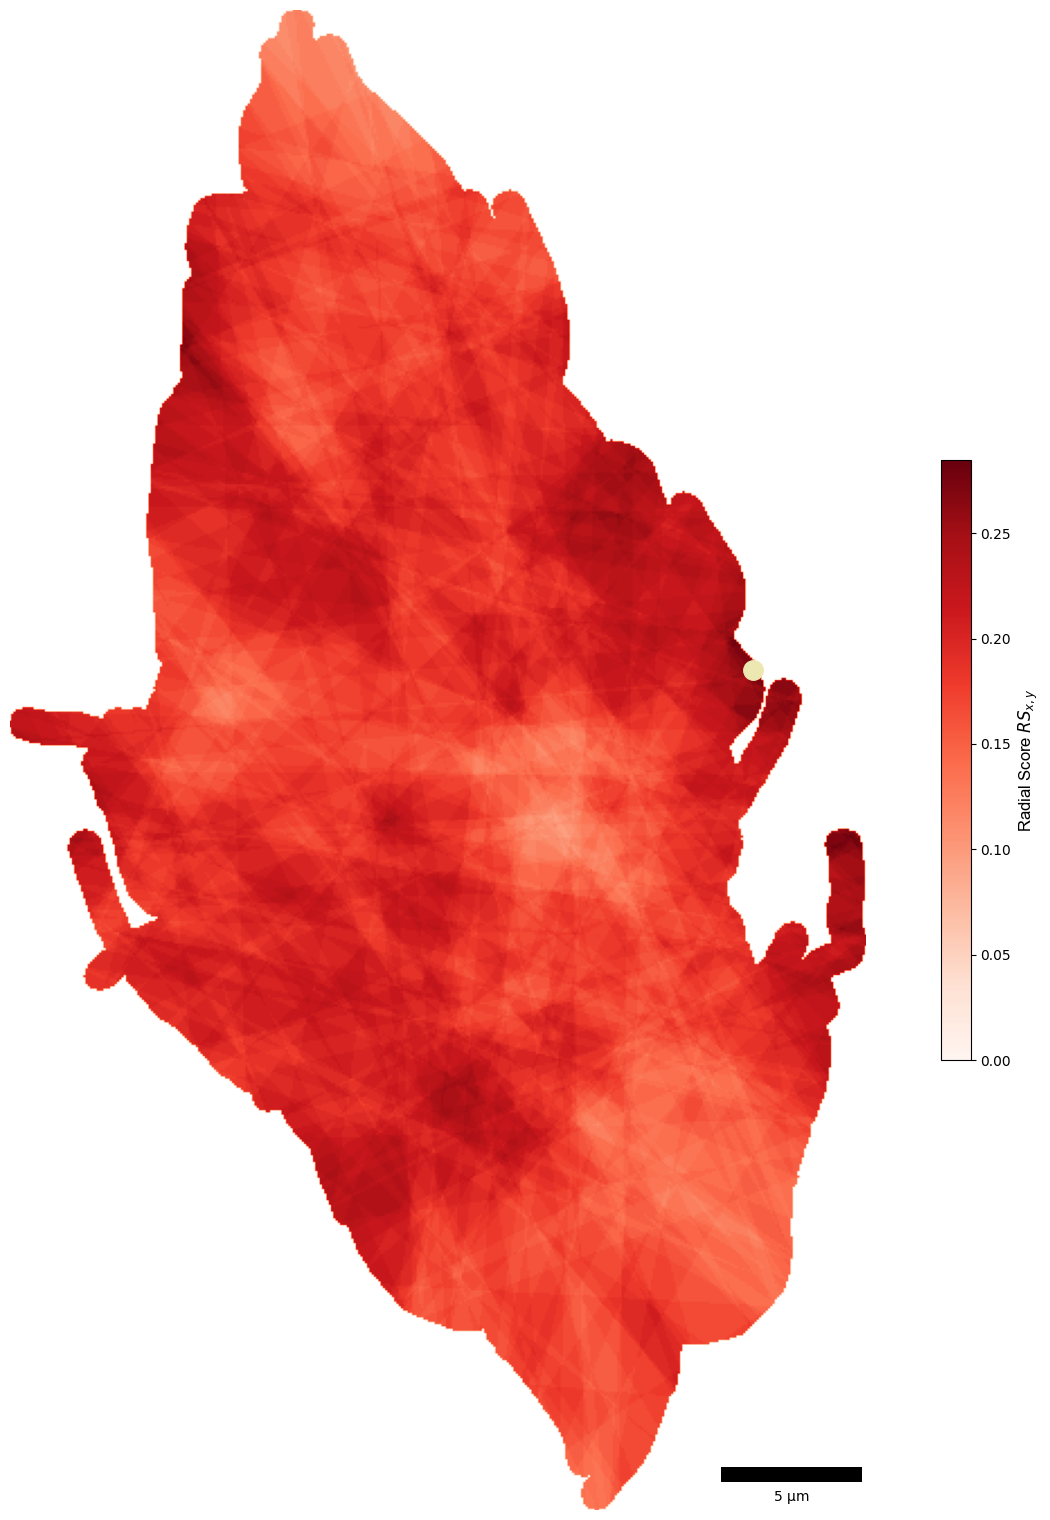

In [4]:
def plot_radial(ResultsRow, overlay=None, normalize_bounds='default', colorbar_label='Radial Score', save=False):
    from skimage.morphology import square, dilation
    from matplotlib_scalebar.scalebar import ScaleBar
    import matplotlib.pyplot as plt
    import matplotlib.cm as pltc
    import matplotlib.colors as colors

    # Create figure
    fig, ax = plt.subplots(figsize=(15, 15))

    # Get radial map and dilate slightly for smoother visualization    DILATE EQUAL TO SUBSAMPLE MASK
    t = dilation(ResultsRow['CNF3D:Radial Map'], square(1))
    
    # Load mask directly
    mask = retrieve_mask(ResultsRow['Mask Filled'],ResultsRow['Image Size'])
    
    x_, y_ = np.where(mask)
    

    # Plot background
    if overlay is None:
        ax.imshow(np.zeros(mask.shape), cmap='gray', alpha=0)
    elif overlay == 'sk':
        skel = retrieve_mask(ResultsRow['Skeleton'], ResultsRow['Image Size'])
        ax.imshow(1 - mask * skel, cmap='gray', alpha=0.5)

    # Plot Radial Score map
    mycmap = pltc.get_cmap('Reds')
    mycmap.set_under('w')
    print(np.max(t * mask))
    ax.imshow(t * mask, cmap=mycmap, vmin=0.001, vmax=1*np.max(t * mask))  # Now just t * mask
    ax.axis('off')

    # Plot points: Nucleus centroid, Nucleus contour, Max radial score position
    if 'Nucleus Centroid' in ResultsRow.keys():
        ax.plot(ResultsRow['Nucleus Centroid'][1], ResultsRow['Nucleus Centroid'][0],
                'o', color='#6495ED', markersize=12, zorder=8)
    if 'Nucleus Contour' in ResultsRow.keys():
        ax.plot(ResultsRow['Nucleus Contour'][:, 0], ResultsRow['Nucleus Contour'][:, 1],
                '--', color='#6495ED', zorder=11, linewidth=2.5)
    if 'CNF2D:Radial Pos' in ResultsRow.keys():
        pos = ResultsRow['CNF2D:Radial Pos'][0]
        ax.plot(pos[1], pos[0], 'o', color='#EDE7B1', markersize=14, zorder=12)

    # Normalize bounds
    if normalize_bounds == 'default':
        normalize_bounds = [0, np.max(t * mask)]

    # Colorbar
    if colorbar_label is not None:
        cbar = fig.colorbar(
            pltc.ScalarMappable(norm=plt.Normalize(normalize_bounds[0], normalize_bounds[1]), cmap=mycmap),
            ax=ax, shrink=0.4
        )
        cbar.set_label(colorbar_label, fontfamily='arial', fontsize=12)

    # Scale bar
    scalebar = ScaleBar(ResultsRow['Resolution'][1], "um", color='k', box_alpha=0, dimension='si-length', location='lower right')
    ax.add_artist(scalebar)

    # Set plot limits
    #ax.set_ylim([min(x_), max(x_)])
    #ax.set_xlim([min(y_), max(y_)])
    ax.set_ylim([max(x_),min(x_)]) # different axes
    ax.set_xlim([min(y_),max(y_)]) # different axes

    # Adjust and save
    fig.tight_layout(pad=0)
    if save != False:
            #plt.savefig(folder + str("\\") + str(save) + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
            plt.savefig(str(save) + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
    fig.show()
    return fig

                                                                                   
fig_rad = plot_radial(ResultsRow       = ResultsDF.loc[cell], 
                      overlay          = None, 
                      normalize_bounds = 'default',
                      colorbar_label   = 'Radial Score $RS_{x,y}$',
                      save             = os.path.join(sfolder,"radialmap")) 

0.2152777777777778


C:\Users\diogo\AppData\Local\Temp\ipykernel_13292\887863714.py:72: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


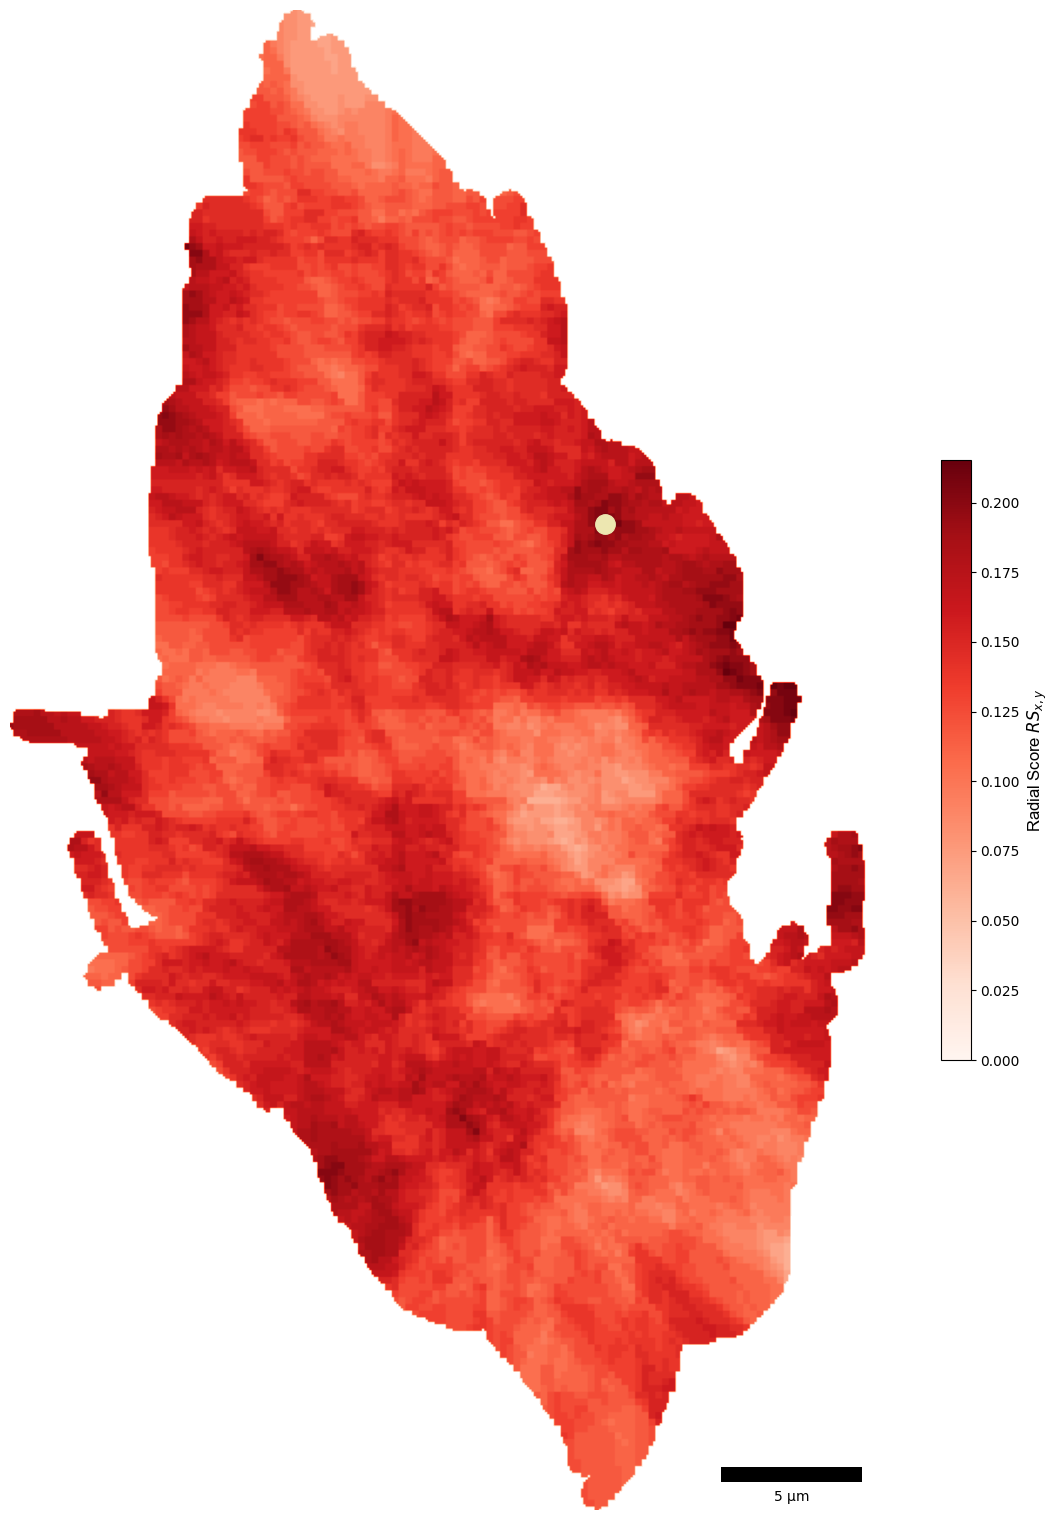

In [5]:
def plot_radial(ResultsRow, overlay=None, normalize_bounds='default', colorbar_label='Radial Score', save=False):
    from skimage.morphology import square, dilation
    from matplotlib_scalebar.scalebar import ScaleBar
    import matplotlib.pyplot as plt
    import matplotlib.cm as pltc
    import matplotlib.colors as colors

    # Create figure
    fig, ax = plt.subplots(figsize=(15, 15))

    # Get radial map and dilate slightly for smoother visualization    DILATE EQUAL TO SUBSAMPLE MASK
    t = dilation(ResultsRow['CNF3D:Radial Map'], square(3))
    
    # Load mask directly
    mask = retrieve_mask(ResultsRow['Mask Filled'],ResultsRow['Image Size'])
    
    x_, y_ = np.where(mask)
    

    # Plot background
    if overlay is None:
        ax.imshow(np.zeros(mask.shape), cmap='gray', alpha=0)
    elif overlay == 'sk':
        skel = retrieve_mask(ResultsRow['Skeleton'], ResultsRow['Image Size'])
        ax.imshow(1 - mask * skel, cmap='gray', alpha=0.5)

    # Plot Radial Score map
    mycmap = pltc.get_cmap('Reds')
    mycmap.set_under('w')
    print(np.max(t * mask))
    ax.imshow(t * mask, cmap=mycmap, vmin=0.001, vmax=1*np.max(t * mask))  # Now just t * mask
    ax.axis('off')

    # Plot points: Nucleus centroid, Nucleus contour, Max radial score position
    if 'Nucleus Centroid' in ResultsRow.keys():
        ax.plot(ResultsRow['Nucleus Centroid'][1], ResultsRow['Nucleus Centroid'][0],
                'o', color='#6495ED', markersize=12, zorder=8)
    if 'Nucleus Contour' in ResultsRow.keys():
        ax.plot(ResultsRow['Nucleus Contour'][:, 0], ResultsRow['Nucleus Contour'][:, 1],
                '--', color='#6495ED', zorder=11, linewidth=2.5)
    if 'CNF2D:Radial Pos' in ResultsRow.keys():
        pos = ResultsRow['CNF2D:Radial Pos'][0]
        ax.plot(pos[1], pos[0], 'o', color='#EDE7B1', markersize=14, zorder=12)

    # Normalize bounds
    if normalize_bounds == 'default':
        normalize_bounds = [0, np.max(t * mask)]

    # Colorbar
    if colorbar_label is not None:
        cbar = fig.colorbar(
            pltc.ScalarMappable(norm=plt.Normalize(normalize_bounds[0], normalize_bounds[1]), cmap=mycmap),
            ax=ax, shrink=0.4
        )
        cbar.set_label(colorbar_label, fontfamily='arial', fontsize=12)

    # Scale bar
    scalebar = ScaleBar(ResultsRow['Resolution'][1], "um", color='k', box_alpha=0, dimension='si-length', location='lower right')
    ax.add_artist(scalebar)

    # Set plot limits
    #ax.set_ylim([min(x_), max(x_)])
    #ax.set_xlim([min(y_), max(y_)])
    ax.set_ylim([max(x_),min(x_)]) # different axes
    ax.set_xlim([min(y_),max(y_)]) # different axes

    # Adjust and save
    fig.tight_layout(pad=0)
    if save != False:
            #plt.savefig(folder + str("\\") + str(save) + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
            plt.savefig(str(save) + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
    fig.show()
    return fig

                                                                                   
fig_rad = plot_radial(ResultsRow       = ResultsDF.loc[cell], 
                      overlay          = None, 
                      normalize_bounds = 'default',
                      colorbar_label   = 'Radial Score $RS_{x,y}$',
                      save             = os.path.join(sfolder,"radialmap")) 

0.3472222222222222


C:\Users\diogo\AppData\Local\Temp\ipykernel_16888\887863714.py:72: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


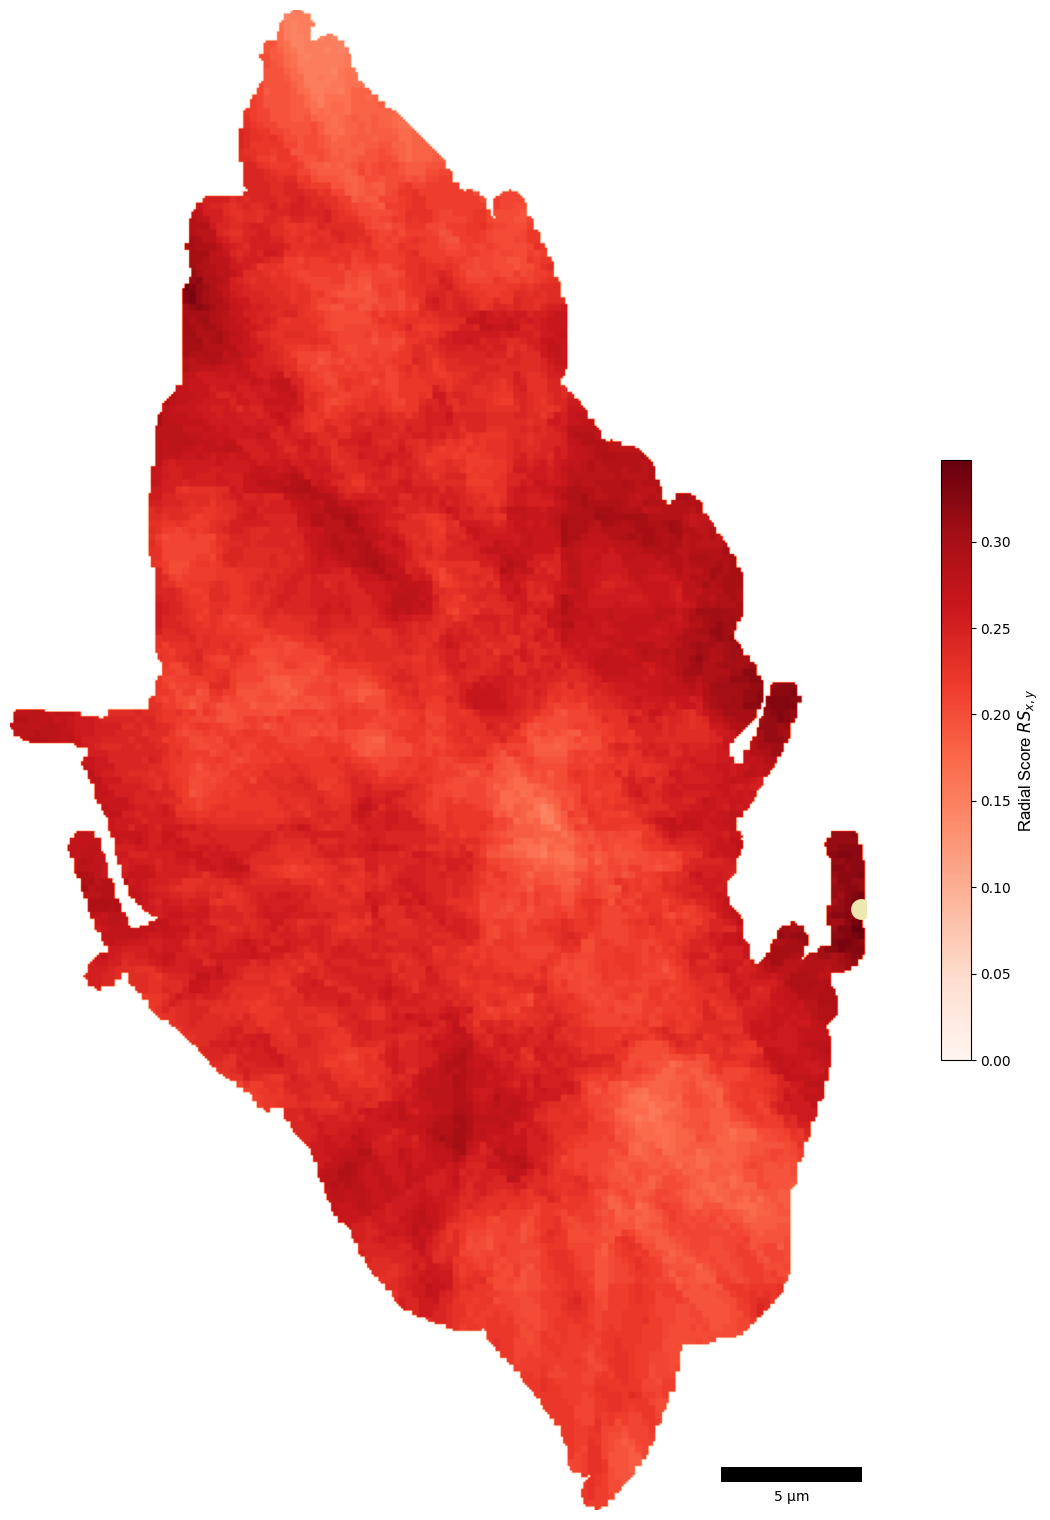

In [4]:
def plot_radial(ResultsRow, overlay=None, normalize_bounds='default', colorbar_label='Radial Score', save=False):
    from skimage.morphology import square, dilation
    from matplotlib_scalebar.scalebar import ScaleBar
    import matplotlib.pyplot as plt
    import matplotlib.cm as pltc
    import matplotlib.colors as colors

    # Create figure
    fig, ax = plt.subplots(figsize=(15, 15))

    # Get radial map and dilate slightly for smoother visualization    DILATE EQUAL TO SUBSAMPLE MASK
    t = dilation(ResultsRow['CNF3D:Radial Map'], square(3))
    
    # Load mask directly
    mask = retrieve_mask(ResultsRow['Mask Filled'],ResultsRow['Image Size'])
    
    x_, y_ = np.where(mask)
    

    # Plot background
    if overlay is None:
        ax.imshow(np.zeros(mask.shape), cmap='gray', alpha=0)
    elif overlay == 'sk':
        skel = retrieve_mask(ResultsRow['Skeleton'], ResultsRow['Image Size'])
        ax.imshow(1 - mask * skel, cmap='gray', alpha=0.5)

    # Plot Radial Score map
    mycmap = pltc.get_cmap('Reds')
    mycmap.set_under('w')
    print(np.max(t * mask))
    ax.imshow(t * mask, cmap=mycmap, vmin=0.001, vmax=1*np.max(t * mask))  # Now just t * mask
    ax.axis('off')

    # Plot points: Nucleus centroid, Nucleus contour, Max radial score position
    if 'Nucleus Centroid' in ResultsRow.keys():
        ax.plot(ResultsRow['Nucleus Centroid'][1], ResultsRow['Nucleus Centroid'][0],
                'o', color='#6495ED', markersize=12, zorder=8)
    if 'Nucleus Contour' in ResultsRow.keys():
        ax.plot(ResultsRow['Nucleus Contour'][:, 0], ResultsRow['Nucleus Contour'][:, 1],
                '--', color='#6495ED', zorder=11, linewidth=2.5)
    if 'CNF2D:Radial Pos' in ResultsRow.keys():
        pos = ResultsRow['CNF2D:Radial Pos'][0]
        ax.plot(pos[1], pos[0], 'o', color='#EDE7B1', markersize=14, zorder=12)

    # Normalize bounds
    if normalize_bounds == 'default':
        normalize_bounds = [0, np.max(t * mask)]

    # Colorbar
    if colorbar_label is not None:
        cbar = fig.colorbar(
            pltc.ScalarMappable(norm=plt.Normalize(normalize_bounds[0], normalize_bounds[1]), cmap=mycmap),
            ax=ax, shrink=0.4
        )
        cbar.set_label(colorbar_label, fontfamily='arial', fontsize=12)

    # Scale bar
    scalebar = ScaleBar(ResultsRow['Resolution'][1], "um", color='k', box_alpha=0, dimension='si-length', location='lower right')
    ax.add_artist(scalebar)

    # Set plot limits
    #ax.set_ylim([min(x_), max(x_)])
    #ax.set_xlim([min(y_), max(y_)])
    ax.set_ylim([max(x_),min(x_)]) # different axes
    ax.set_xlim([min(y_),max(y_)]) # different axes

    # Adjust and save
    fig.tight_layout(pad=0)
    if save != False:
            #plt.savefig(folder + str("\\") + str(save) + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
            plt.savefig(str(save) + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
    fig.show()
    return fig

                                                                                   
fig_rad = plot_radial(ResultsRow       = ResultsDF.loc[cell], 
                      overlay          = None, 
                      normalize_bounds = 'default',
                      colorbar_label   = 'Radial Score $RS_{x,y}$',
                      save             = os.path.join(sfolder,"radialmap")) 

In [27]:
ResultsDF.loc[0]['CNF1D:Radial Score']

0.444

### COMPLEXITY

In [196]:
def boxcount_fractal_dimension(binary_img, rotation_angles=None):
    import numpy as np
    from scipy.ndimage import rotate

    def _boxcount_fd(Z):
        Z = np.asarray(Z, dtype=bool)
        if Z.ndim != 2:
            raise ValueError("binary_img must be 2D")
        if not np.any(Z):
            return np.nan

        h, w = Z.shape
        p = min(h, w)
        max_pow = int(np.floor(np.log2(p)))
        if max_pow < 1:
            return np.nan

        sizes = 2 ** np.arange(max_pow, 0, -1)

        counts = []
        valid_sizes = []

        for size in sizes:
            hh = (h // size) * size
            ww = (w // size) * size
            if hh == 0 or ww == 0:
                continue

            cropped = Z[:hh, :ww]
            blocks = cropped.reshape(hh // size, size, ww // size, size)
            n = np.count_nonzero(blocks.any(axis=(1, 3)))

            if n > 0:
                counts.append(n)
                valid_sizes.append(size)

        if len(valid_sizes) < 2:
            return np.nan

        x = np.log(1 / np.array(valid_sizes, dtype=float))
        y = np.log(np.array(counts, dtype=float))
        slope, _ = np.polyfit(x, y, 1)
        return float(slope)

    Z = np.asarray(binary_img, dtype=bool)

    if rotation_angles is None:
        return _boxcount_fd(Z)

    fds = []
    for ang in rotation_angles:
        if ang == 0:
            Zr = Z
        else:
            Zr = rotate(
                Z.astype(float),
                angle=ang,
                reshape=False,
                order=0,
                mode='constant',
                cval=0.0,
                prefilter=False
            ) > 0.5

        fd = _boxcount_fd(Zr)
        if np.isfinite(fd):
            fds.append(fd)

    if len(fds) == 0:
        return np.nan

    return float(np.mean(fds))

def compute_fractal_dimension_spatial(
    ResultsRow,
    tile_size=48,
    source='skeleton',   # 'skeleton' or 'mask'
    min_mask_fraction=0.01,
    rotation_angles=None
):
    import numpy as np

    mask = retrieve_mask(ResultsRow['Mask Filled'], ResultsRow['Image Size']).astype(bool)

    if source == 'skeleton':
        img = retrieve_mask(ResultsRow['Skeleton'], ResultsRow['Image Size']).astype(bool)
        work = img & mask
    elif source == 'mask':
        work = mask.copy()
    else:
        raise ValueError("source must be 'skeleton' or 'mask'")

    h, w = mask.shape
    fmap = np.full((h, w), np.nan, dtype=float)
    tile_boxes = []

    for r0 in range(0, h, tile_size):
        for c0 in range(0, w, tile_size):
            r1 = min(r0 + tile_size, h)
            c1 = min(c0 + tile_size, w)

            tile_mask = mask[r0:r1, c0:c1]
            if tile_mask.mean() < min_mask_fraction:
                continue

            tile = work[r0:r1, c0:c1]
            fd = boxcount_fractal_dimension(tile, rotation_angles=rotation_angles)

            fmap[r0:r1, c0:c1] = fd
            tile_boxes.append((r0, r1, c0, c1))

    return fmap, tile_boxes

In [197]:
from matplotlib import cm, colors

def plot_fractal_map(ResultsRow, overlay=None, normalize_bounds='auto',
                     colorbar_label='Local fractal dimension $D_f$',
                     cmap_name='rainbow', save=False,
                     tile_boxes=None, tile_edgecolor='black', tile_linewidth=0.4,
                     show_tile_fill=False, tile_fill_alpha=0.25,
                     show_skeleton=True, skeleton_size=7):
    from matplotlib_scalebar.scalebar import ScaleBar
    from matplotlib.patches import Rectangle
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(8, 8))

    fmap = ResultsRow['CNF3D:Fractal Dimension Spatial']
    mask = retrieve_mask(ResultsRow['Mask Filled'], ResultsRow['Image Size']).astype(bool)
    skel = retrieve_mask(ResultsRow['Skeleton'], ResultsRow['Image Size']).astype(bool)

    t = fmap.copy()

    base_cmap = cm.get_cmap(cmap_name).copy()
    base_cmap.set_bad(color='white')
    base_cmap.set_under(color='white')

    finite_vals = t[np.isfinite(t) & mask]
    if finite_vals.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        if normalize_bounds == 'auto':
            vmin, vmax = np.nanpercentile(finite_vals, [2, 98])
        elif normalize_bounds == 'default':
            vmin, vmax = np.nanmin(finite_vals), np.nanmax(finite_vals)
        else:
            vmin, vmax = normalize_bounds

    vmin = max(vmin, 1e-6)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    ax.axis('off')

    # optional faint tile fill
    if show_tile_fill:
        t_ma = np.ma.masked_invalid(t)
        ax.imshow(
            t_ma * mask,
            cmap=base_cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation='nearest',
            alpha=tile_fill_alpha,
            zorder=1
        )

    # skeleton pixels colored by FD of their tile
    if show_skeleton:
        rr, cc = np.where(skel & mask & np.isfinite(t))
        skel_vals = t[rr, cc]
        skel_colors = base_cmap(norm(skel_vals))
        ax.scatter(
            cc, rr,
            c=skel_colors,
            s=skeleton_size,
            marker='s',
            linewidths=0,
            zorder=10
        )

    # tile outlines
    if tile_boxes is not None:
        for r0, r1, c0, c1 in tile_boxes:
            rect = Rectangle(
                (c0, r0), c1 - c0, r1 - r0,
                fill=False,
                edgecolor=tile_edgecolor,
                linewidth=tile_linewidth,
                zorder=20
            )
            ax.add_patch(rect)

#     if 'Nucleus Centroid' in ResultsRow:
#         ax.plot(ResultsRow['Nucleus Centroid'][1], ResultsRow['Nucleus Centroid'][0],
#                 'o', color='#6495ED', markersize=12, zorder=25)
#     if 'Nucleus Contour' in ResultsRow:
#         ax.plot(ResultsRow['Nucleus Contour'][:, 0], ResultsRow['Nucleus Contour'][:, 1],
#                 '--', color='#6495ED', zorder=25, linewidth=2.5)

    if colorbar_label and finite_vals.size:
        cbar = fig.colorbar(
            cm.ScalarMappable(norm=norm, cmap=base_cmap),
            ax=ax,
            shrink=0.4
        )
        cbar.set_label(colorbar_label, fontfamily='arial', fontsize=12)

    scalebar = ScaleBar(
        ResultsRow['Resolution'][1], "um",
        color='k', box_alpha=0,
        dimension='si-length',
        location='lower right'
    )
    ax.add_artist(scalebar)

    # crop using both mask bounds and tile-box bounds so outer boxes are not cut
    x_, y_ = np.where(mask)

    xmin = np.min(y_)
    xmax = np.max(y_)
    ymin = np.min(x_)
    ymax = np.max(x_)

    if tile_boxes is not None and len(tile_boxes) > 0:
        tile_xmin = min(c0 for r0, r1, c0, c1 in tile_boxes)
        tile_xmax = max(c1 for r0, r1, c0, c1 in tile_boxes)
        tile_ymin = min(r0 for r0, r1, c0, c1 in tile_boxes)
        tile_ymax = max(r1 for r0, r1, c0, c1 in tile_boxes)

        xmin = min(xmin, tile_xmin)
        xmax = max(xmax, tile_xmax)
        ymin = min(ymin, tile_ymin)
        ymax = max(ymax, tile_ymax)

    pad = 2
    ax.set_xlim([xmin - pad, xmax + pad])
    ax.set_ylim([ymax + pad, ymin - pad])
    ax.set_aspect('equal')

    fig.tight_layout(pad=0)
    if save:
        plt.savefig(str(save) + ".pdf", format='pdf', transparent=True, bbox_inches='tight')
    plt.show()
    return fig

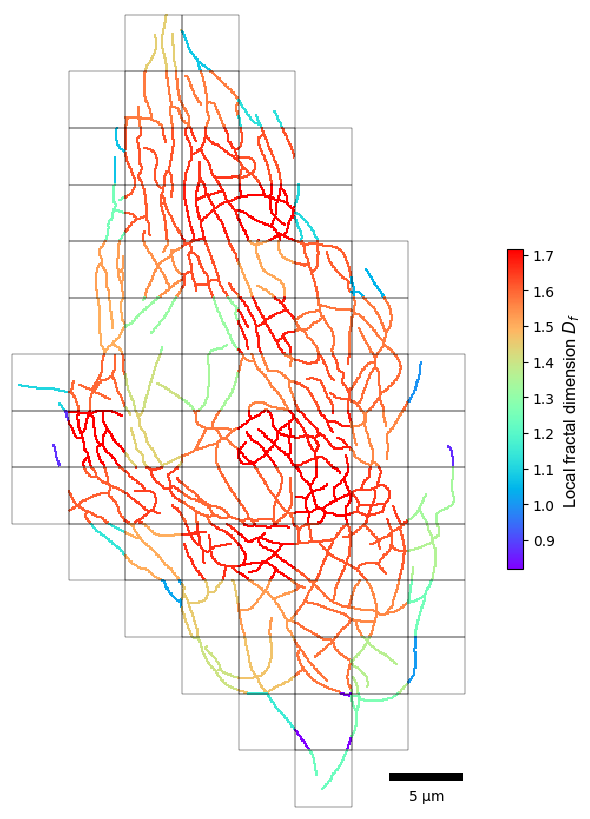

In [200]:
angles = [0, 15, 30, 45, 60, 90, 105, 120, 135, 150, 165]

cell = 0

fmap, tile_boxes = compute_fractal_dimension_spatial(
    ResultsRow=ResultsDF.loc[cell],
    tile_size=48,
    source='skeleton',
    min_mask_fraction=0.05,
    rotation_angles=angles
)

ResultsDF.at[cell, 'CNF3D:Fractal Dimension Spatial'] = fmap

fig_fd = plot_fractal_map(
    ResultsRow=ResultsDF.loc[cell],
    normalize_bounds='auto',
    colorbar_label=r'Local fractal dimension $D_f$',
    tile_boxes=tile_boxes,
    tile_edgecolor='black',
    tile_linewidth=0.3,
    show_tile_fill=False,      # key change
    show_skeleton=True,
    skeleton_size=3,
    save=os.path.join(sfolder, "fractalmap")
)

Global aligned FD (mean over rotations): 1.3962018590820557
Nucleus major-axis angle (deg): 73.92221722176171
Rotation applied to align cell (deg): 16.077782778238287


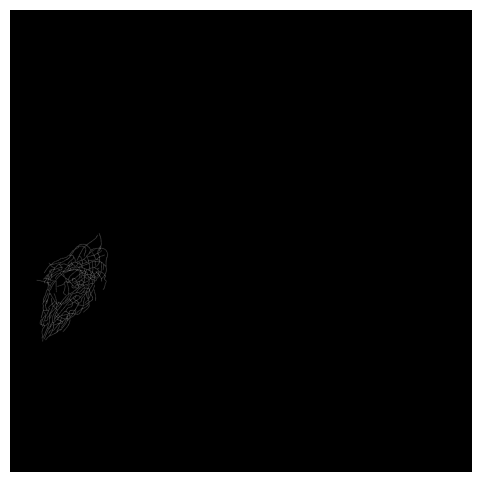

In [202]:
def boxcount_fractal_dimension(binary_img, rotation_angles=None):
    import numpy as np
    from scipy.ndimage import rotate

    def _boxcount_fd(Z):
        Z = np.asarray(Z, dtype=bool)
        if Z.ndim != 2:
            raise ValueError("binary_img must be 2D")
        if not np.any(Z):
            return np.nan

        h, w = Z.shape
        p = min(h, w)
        max_pow = int(np.floor(np.log2(p)))
        if max_pow < 1:
            return np.nan

        sizes = 2 ** np.arange(max_pow, 0, -1)

        counts = []
        valid_sizes = []

        for size in sizes:
            hh = (h // size) * size
            ww = (w // size) * size
            if hh == 0 or ww == 0:
                continue

            cropped = Z[:hh, :ww]
            blocks = cropped.reshape(hh // size, size, ww // size, size)
            n = np.count_nonzero(blocks.any(axis=(1, 3)))

            if n > 0:
                counts.append(n)
                valid_sizes.append(size)

        if len(valid_sizes) < 2:
            return np.nan

        x = np.log(1 / np.array(valid_sizes, dtype=float))
        y = np.log(np.array(counts, dtype=float))
        slope, _ = np.polyfit(x, y, 1)
        return float(slope)

    Z = np.asarray(binary_img, dtype=bool)

    if rotation_angles is None:
        return _boxcount_fd(Z)

    fds = []
    for ang in rotation_angles:
        if ang == 0:
            Zr = Z
        else:
            Zr = rotate(
                Z.astype(float),
                angle=ang,
                reshape=False,
                order=0,
                mode='constant',
                cval=0.0,
                prefilter=False
            ) > 0.5

        fd = _boxcount_fd(Zr)
        if np.isfinite(fd):
            fds.append(fd)

    if len(fds) == 0:
        return np.nan

    return float(np.mean(fds))

def align_binary_to_nucleus_major_axis(binary_img, nucleus_contour):
    import numpy as np
    from scipy.ndimage import rotate

    pts = np.asarray(nucleus_contour, dtype=float)
    if pts.ndim != 2 or pts.shape[1] != 2:
        raise ValueError("nucleus_contour must be an array of shape (N, 2) with columns [x, y]")

    # PCA on contour points
    centered = pts - pts.mean(axis=0, keepdims=True)
    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    major_vec = eigvecs[:, np.argmax(eigvals)]

    # angle of major axis w.r.t. +x axis
    major_angle_deg = np.degrees(np.arctan2(major_vec[1], major_vec[0]))

    # rotate so nucleus major axis becomes vertical (90°)
    rot_to_vertical_deg = 90.0 - major_angle_deg

    aligned = rotate(
        np.asarray(binary_img, dtype=float),
        angle=rot_to_vertical_deg,
        reshape=True,
        order=0,
        mode='constant',
        cval=0.0,
        prefilter=False
    ) > 0.5

    return aligned, rot_to_vertical_deg, major_angle_deg

def compute_global_fractal_dimension_aligned(
    ResultsRow,
    source='skeleton',   # 'skeleton' or 'mask'
    rotation_angles=(0, 15, 30, 45, 60, 90, 105, 120, 135, 150, 165)
):
    import numpy as np

    mask = retrieve_mask(ResultsRow['Mask Filled'], ResultsRow['Image Size']).astype(bool)

    if source == 'skeleton':
        img = retrieve_mask(ResultsRow['Skeleton'], ResultsRow['Image Size']).astype(bool)
        work = img & mask
    elif source == 'mask':
        work = mask.copy()
    else:
        raise ValueError("source must be 'skeleton' or 'mask'")

    if 'Nucleus Contour' not in ResultsRow:
        raise ValueError("ResultsRow must contain 'Nucleus Contour' to align by nucleus major axis")

    aligned_img, rot_to_vertical_deg, nucleus_major_angle_deg = align_binary_to_nucleus_major_axis(
        binary_img=work,
        nucleus_contour=ResultsRow['Nucleus Contour']
    )

    fd_mean = boxcount_fractal_dimension(aligned_img, rotation_angles=rotation_angles)

    return {
        'fd_mean': fd_mean,
        'aligned_binary': aligned_img,
        'alignment_rotation_deg': rot_to_vertical_deg,
        'nucleus_major_angle_deg': nucleus_major_angle_deg,
        'rotation_angles_used': tuple(rotation_angles),
        'source': source
    }

# example usage for one cell
angles = (0, 15, 30, 45, 60, 90, 105, 120, 135, 150, 165)

result_fd_global = compute_global_fractal_dimension_aligned(
    ResultsRow=ResultsDF.loc[cell],
    source='skeleton',
    rotation_angles=angles
)

print("Global aligned FD (mean over rotations):", result_fd_global['fd_mean'])
print("Nucleus major-axis angle (deg):", result_fd_global['nucleus_major_angle_deg'])
print("Rotation applied to align cell (deg):", result_fd_global['alignment_rotation_deg'])

ResultsDF.at[cell, 'CNF2D:Fractal Dimension Global Aligned'] = result_fd_global['fd_mean']

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(result_fd_global['aligned_binary'], cmap='gray', origin='lower')
plt.axis('off')
plt.show()

### MORPHOLOGY: CURVATURE

C:\Users\diogo\AppData\Local\Temp\ipykernel_5460\3313784375.py:155: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


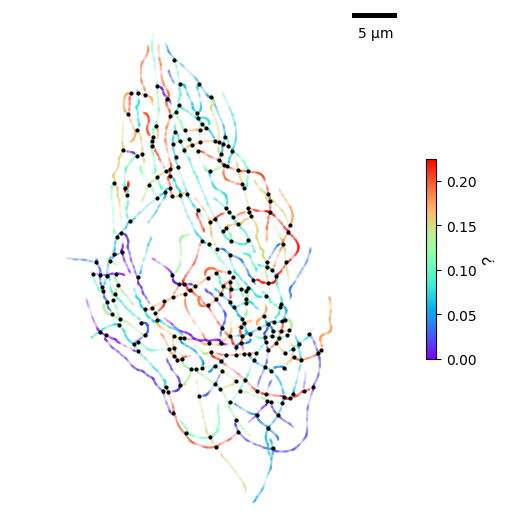

In [38]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF2D:Branch Curvatures',   # CUIDADO DEVIA SER CNF3D
                     nodes               = True,
                     colorbar_label      = '?',
                     bounds              = 'default',
                     overlay             = None, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"curvatures"))

C:\Users\diogo\AppData\Local\Temp\ipykernel_31244\2379284878.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


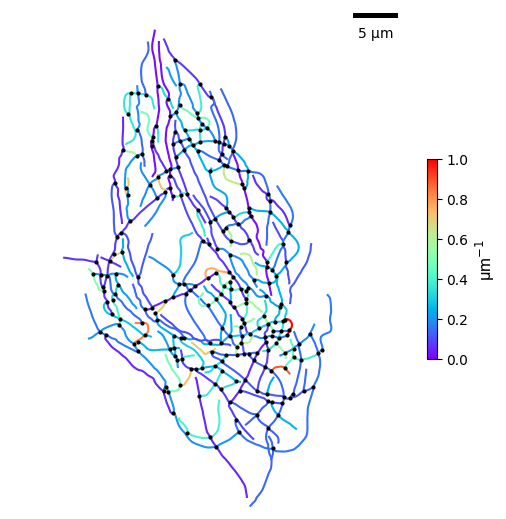

In [42]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF2D:Branch Menger Curvatures',
                     nodes               = True,
                     colorbar_label      = r'μm$^{-1}$',
                     bounds              = [0,1],
                     overlay             = None, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"meng_curv"))




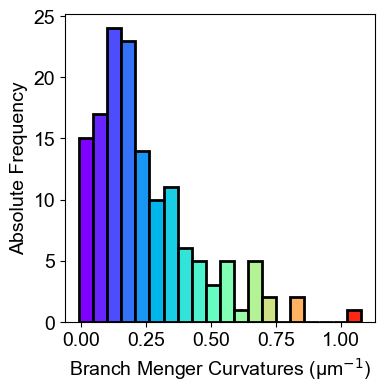

In [34]:
plot_histogram(ResultsRow = ResultsDF.loc[0],
                    data  = data,
                    feat  = "CNF2D:Branch Menger Curvatures",
                    units = r'μm$^{-1}$',
                    bins  = 20,
                    save  = os.path.join(sfolder,"hist_branchmengercurvatures"))

### MORPHOLOGY: TORTUOSITY

C:\Users\diogo\AppData\Local\Temp\ipykernel_31244\2379284878.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


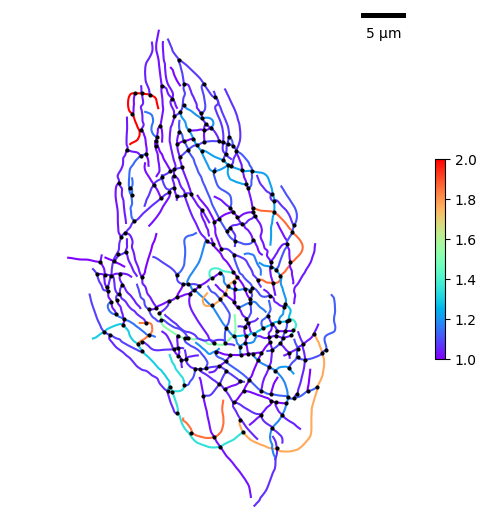

In [55]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF2D:Branch Tortuosities',
                     nodes               = True,
                     colorbar_label      = '',
                     bounds              = [1,2],
                     overlay             = None, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"tortuosities"))

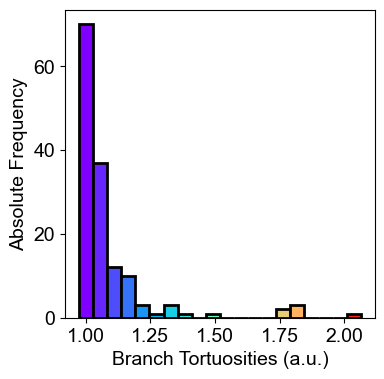

In [37]:
plot_histogram(ResultsRow = ResultsDF.loc[0],
                    data  = data,
                    feat  = "CNF2D:Branch Tortuosities",
                    units = "a.u.",
                    bins  = 20,
                    save  = os.path.join(sfolder,"hist_tortuosities"))

### MORPHOLOGY: LENGTHS

C:\Users\diogo\AppData\Local\Temp\ipykernel_2160\3869575334.py:159: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


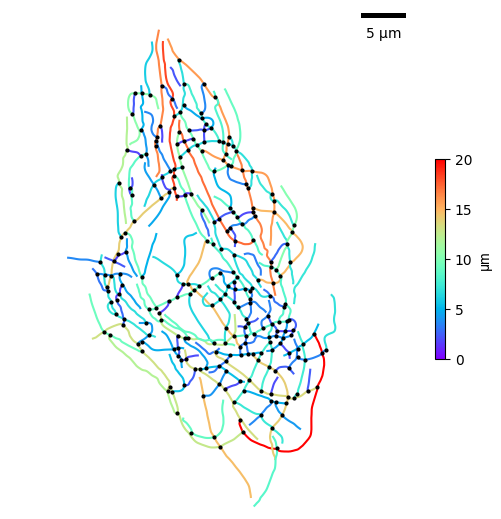

In [63]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF2D:Branch Lengths',
                     nodes               = True,
                     colorbar_label      = 'μm',
                     bounds              = [0,20],
                     overlay             = None, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"lengths"))

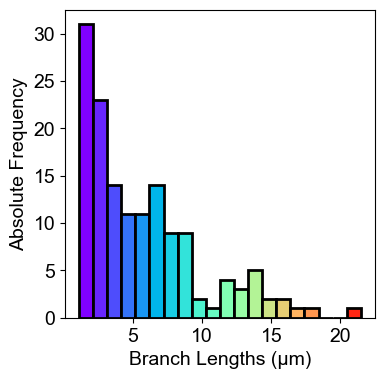

In [36]:
plot_histogram(ResultsRow = ResultsDF.loc[0],
                    data  = data,
                    feat  = "CNF2D:Branch Lengths",
                    units = "μm",
                    bins  = 20,
                    save  = os.path.join(sfolder,"hist_lengths"))


### DENSITY

C:\Users\diogo\AppData\Local\Temp\ipykernel_2160\3435091962.py:117: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


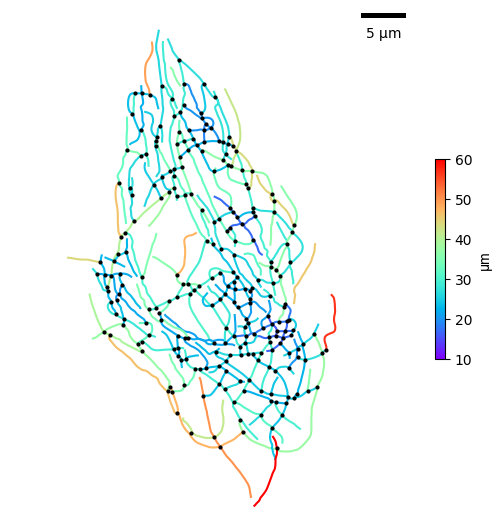

In [95]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF2D:Local Average Branch Distance',
                     nodes               = True,
                     colorbar_label      = 'μm',
                     bounds              = [10,60],
                     overlay             = None, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"localavgbrdist"))

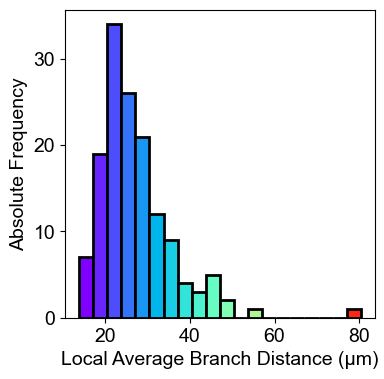

In [94]:
plot_histogram(ResultsRow = ResultsDF.loc[0],
                    data  = data,
                    feat  = "CNF2D:Local Average Branch Distance",
                    units = "μm",
                    bins  = 20,
                    save  = os.path.join(sfolder,"hist_locavgbrdist"))

In [62]:
ratio = np.sum(ResultsDF.loc[0]['Patch:Skeleton'] > 0) / np.sum(ResultsDF.loc[0]['Patch:Cyto Mask'] > 0)

ResultsDF['CNF1D:Sum Skel / Sum Mask'] = [ratio]
ResultsDF['CNF1D:Sum Skel / Sum Mask']

0    0.276259
Name: CNF1D:Sum Skel / Sum Mask, dtype: float64

### DISTANCE TO CELL EDGE

C:\Users\diogo\AppData\Local\Temp\ipykernel_2160\4004915424.py:162: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


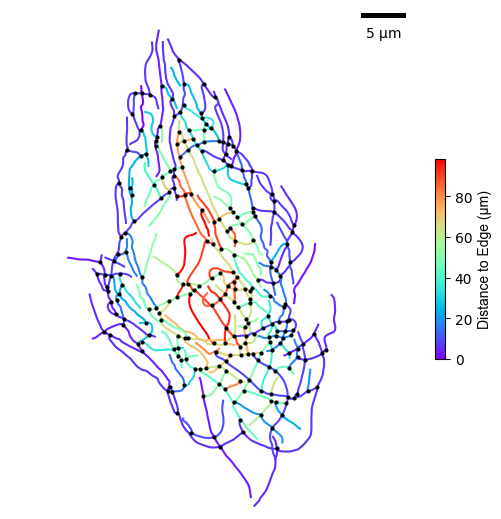

In [38]:
fig_distcelledge = plot_soax(ResultsRow     = ResultsDF.loc[0], 
                             data           = data, 
                             feat           = 'CNF2D:Distance to Edge', 
                             nodes          = True,
                             colorbar_label = 'Distance to Edge (μm)',
                             bounds         = 'default',
                             overlay        = None,
                             scalebar       = True,
                             save           = os.path.join(sfolder,"dist_to_celledge"))


In [10]:
FULL['CNF1D:Thicknesses mean']

KeyError: 'CNF1D:Thicknesses mean'

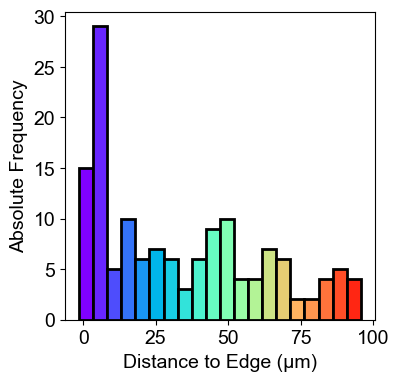

In [39]:
plot_histogram(ResultsRow = ResultsDF.loc[0],
                    data  = data,
                    feat  = "CNF2D:Distance to Edge",
                    units = "μm",
                    bins  = 20,
                    save  = os.path.join(sfolder,"hist_celledgedists"))

### ORIENTATION

In [108]:
def plot_orientations(ResultsRow, bin_size, save):
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.cm as pltc
    from matplotlib.colors import LinearSegmentedColormap

    tick_fontsize = 10
    fontname = 'Arial'

    def circular_rainbow_colormap(n=256):
        base = pltc.get_cmap('rainbow')
        colors = base(np.linspace(0, 1, n, endpoint=False))
        colors = np.vstack([colors, colors[0]])  # force closure: 0° = 180°
        return LinearSegmentedColormap.from_list('circular_rainbow', colors, N=n)

    cmap = circular_rainbow_colormap()

    orientations = 180 - np.array(ResultsRow['CNF2D:Branch Orientations'])

    bins = np.arange(0, 180 + bin_size, bin_size)
    bin_centers_deg = bins[:-1] + bin_size / 2
    bin_centers = np.radians(bin_centers_deg)

    counts, _ = np.histogram(orientations, bins=bins)

    colors = [cmap(angle / 180.0) for angle in bin_centers_deg]

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(4, 4))
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    bar_width = np.radians(bin_size)
    ax.bar(
        bin_centers,
        counts,
        width=bar_width,
        bottom=0,
        color=colors,
        alpha=1,
        edgecolor='black',
        zorder=5,
    )

    ax.set_thetamin(0)
    ax.set_thetamax(180)

    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

    theta_ticks = [0, 30, 60, 90, 120, 150, 180]
    ax.set_thetagrids(
        theta_ticks,
        labels=[f"{t}°" for t in theta_ticks],
        fontsize=tick_fontsize,
        fontname=fontname
    )

    for label in ax.get_yticklabels():
        label.set_fontname(fontname)
        label.set_fontsize(tick_fontsize)

    ax.set_facecolor("white")
    ax.grid(color="black", linestyle="--", linewidth=0.1)

    if save != False:
        plt.savefig(str(save) + ".pdf", format='pdf', transparent=True, bbox_inches='tight')

    plt.show()
    return fig

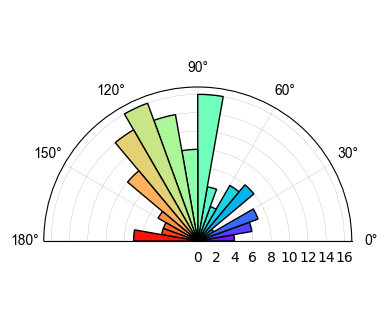

In [106]:

# Example usage with ResultsRow
fig_orientation = plot_orientations(
    ResultsRow=ResultsDF.loc[0],  # Replace with your DataFrame row
    bin_size=10,
    save = os.path.join(sfolder,"orients_semicirc")
)


In [109]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
import numpy as np

def circular_rainbow_colormap(n=256, base_cmap='rainbow'):
    base = cm.get_cmap(base_cmap)

    # sample rainbow, then force closure by repeating the first color at the end
    colors = base(np.linspace(0, 1, n, endpoint=False))
    colors = np.vstack([colors, colors[0]])

    return LinearSegmentedColormap.from_list('circular_rainbow', colors, N=n)

C:\Users\diogo\AppData\Local\Temp\ipykernel_2160\118774276.py:116: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


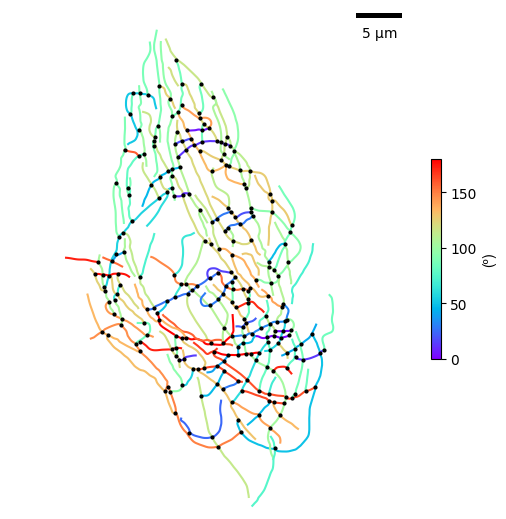

In [110]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF2D:Branch Orientations',
                     nodes               = True,
                     colorbar_label      = '(º)',
                     bounds              = 'default',
                     overlay             = None, 
                     scalebar            = True,
                     save                = False)

C:\Users\diogo\AppData\Local\Temp\ipykernel_2160\118774276.py:116: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


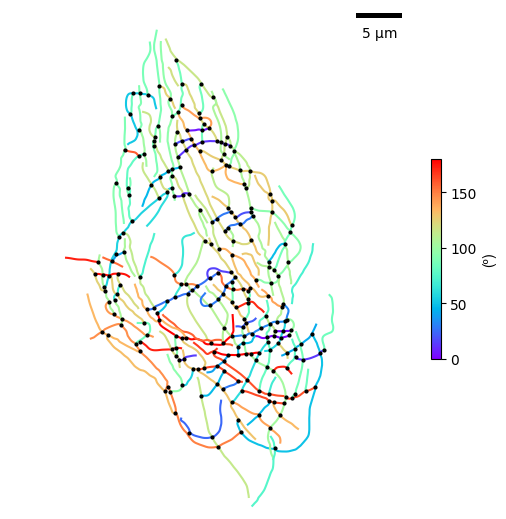

In [111]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF2D:Branch Orientations',
                     nodes               = True,
                     colorbar_label      = '(º)',
                     bounds              = 'default',
                     overlay             = None, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"orientations"))

(array([10.,  8., 20., 25., 21., 20., 11., 11.,  9.,  9.]),
 array([  1.24716897,  19.01548637,  36.78380377,  54.55212117,
         72.32043857,  90.08875597, 107.85707337, 125.62539077,
        143.39370817, 161.16202557, 178.93034297]),
 <BarContainer object of 10 artists>)

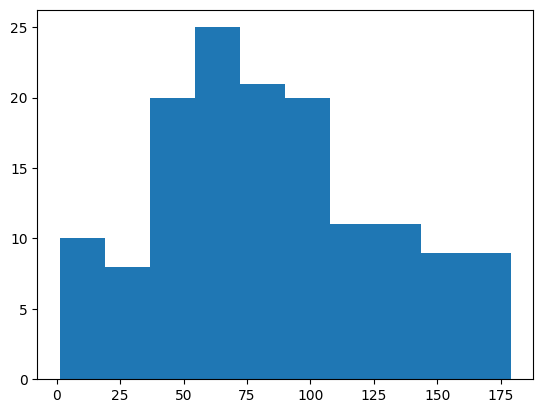

In [20]:
plt.hist(ResultsDF['CNF2D:Branch Orientations'][0])

In [42]:
#CV OF PARALLELISM, BREUER
np.std(ResultsDF.loc[0]['CNF2D:Branch Orientations (Long Axis)']) / np.mean(ResultsDF.loc[0]['CNF2D:Branch Orientations (Long Axis)'])

0.5890652534716946

C:\Users\diogo\AppData\Local\Temp\ipykernel_5460\453994220.py:136: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


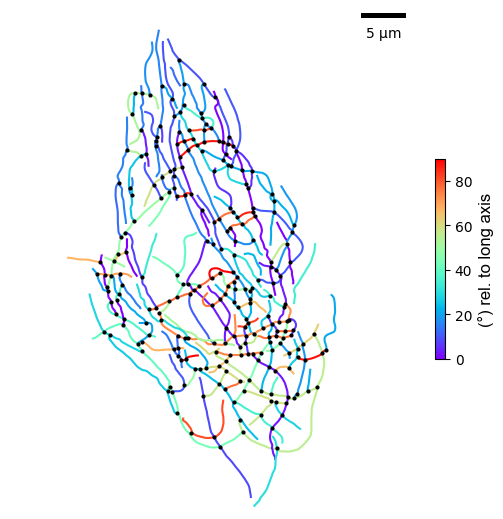

In [9]:
fig_orientlongaxis = plot_soax(ResultsRow     = ResultsDF.loc[0], 
                               data           = data, 
                               feat           = 'CNF2D:Branch Orientations (Long Axis)', 
                               nodes          = True,
                               colorbar_label = '(°) rel. to long axis',
                               bounds         = 'default',
                               overlay        = None,
                               scalebar       = True,
                               save           = os.path.join(sfolder,"orient_longaxis"))


In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def plot_filled_mask_with_long_axis(mask_filled):
    # 1. Get coordinates of non-zero pixels
    coords = np.column_stack(np.nonzero(mask_filled))  # shape: (N, 2), order: (row, col)

    # 2. Fit PCA to get long axis
    pca = PCA(n_components=2)
    pca.fit(coords)
    center = pca.mean_
    direction = pca.components_[0]  # principal (long) axis

    # 3. Define endpoints of long axis line
    length = 0.2 * np.max(mask_filled.shape)  # you can tune this
    point1 = center - length * direction
    point2 = center + length * direction

    # 4. Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(mask_filled, cmap='gray')
    ax.plot([point1[1], point2[1]], [point1[0], point2[0]], color='red', lw=2)  # col= x, row= y
    ax.scatter(center[1], center[0], color='blue', label='Center')
    ax.set_title("Filled Mask with Long Axis")
    ax.axis('equal')
    plt.legend()
    plt.show()


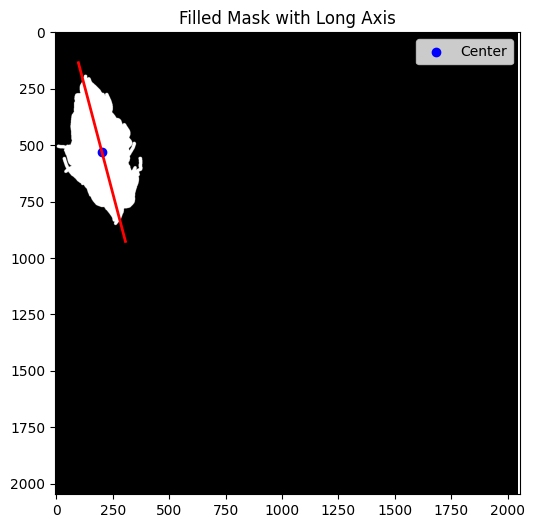

In [11]:
plot_filled_mask_with_long_axis(retrieve_mask(ResultsDF.loc[0]['Mask Filled'], ResultsDF.loc[0]['Image Size']))


In [29]:
def plot_orientations_longaxis(ResultsRow, bin_size, save):
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.cm as pltc
    from matplotlib.colors import Normalize

    # Colormap
    cmap = pltc.rainbow
    norm = Normalize(vmin=0, vmax=90)

    # Extract orientations
    orientations = ResultsRow['CNF2D:Branch Orientations (Long Axis)']  # assumed to be in [0, 90]

    # Create bins for quarter-circle
    bins = np.arange(0, 90 + bin_size, bin_size)
    bin_centers = np.radians(bins[:-1] + bin_size / 2)

    # Histogram
    counts, _ = np.histogram(orientations, bins=bins)
    bar_width = np.radians(bin_size)
    colors = [cmap(norm(np.degrees(angle))) for angle in bin_centers]

    # Plot
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(3, 3))
    ax.set_theta_zero_location("E")  # 0° = right
    ax.set_theta_direction(1)  # Clockwise

    bars = ax.bar(
        bin_centers,
        counts,
        width=bar_width,
        bottom=0,
        color=colors,
        edgecolor='black',
        alpha=1,
        zorder=5
    )

    # Limit to quarter circle
    ax.set_thetamin(0)
    ax.set_thetamax(90)

    #
    #ax.set_rlabel_position(135)  # optional
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([str(int(t)) for t in ax.get_yticks()])
    
    # Clean style
    ax.set_facecolor("white")
    ax.grid(color="black", linestyle="--", linewidth=0.1)
    ax.tick_params(axis='both', which='major', labelsize=10)

    #ax.set_xlabel('μm')
    
    if save:
        plt.savefig(str(save) + ".pdf", format='pdf', transparent=True, bbox_inches='tight')

    plt.show()
    return fig


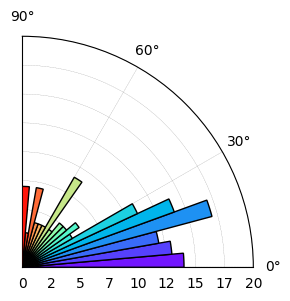

In [30]:
fig_orientation = plot_orientations_longaxis(ResultsRow = ResultsDF.loc[0],  
                                               bin_size =5,
                                                   save = os.path.join(sfolder,"orients_semicirc_longaxis"))


# CONNECTIVITY

In [10]:
data['junctions']

,x,y,z
0,209.738,636.527,0
1,230.122,641.258,0
2,244.156,640.846,0
3,255.110,639.527,0
4,261.125,639.233,0
...,...,...,...
242,285.987,512.736,0
243,149.123,287.097,0
244,207.851,456.928,0
245,107.214,329.569,0


In [3]:
import numpy as np
import pandas as pd

def count_filament_connections(data, threshold=2):
    junctions_df = data['junctions']
    filaments_df = data['filaments']
    # Extract junction coordinates as a NumPy array
    junction_coords = junctions_df[['x', 'y']].values
    
    connections = []  # To store the number of connections for each filament

    for filament_df in filaments_df:
        # Get the start and end coordinates of the filament
        start_point = filament_df.iloc[0][['x', 'y']].values
        end_point = filament_df.iloc[-1][['x', 'y']].values

        # Check for proximity to junctions
        start_matches = np.any(np.linalg.norm(junction_coords - start_point, axis=1) <= threshold)
        end_matches = np.any(np.linalg.norm(junction_coords - end_point, axis=1) <= threshold)

        # Count how many junctions the filament is connected to
        connections.append(sum([start_matches, end_matches]))
        
    

    return connections

connections = count_filament_connections(data)
# ACHO QUE NAO ESTA BEM, MAS CONFIRMAR

In [4]:
ResultsDF['CNF2D:Branch Connectivity Type'] = [connections]

C:\Users\diogo\AppData\Local\Temp\ipykernel_2160\3435091962.py:117: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


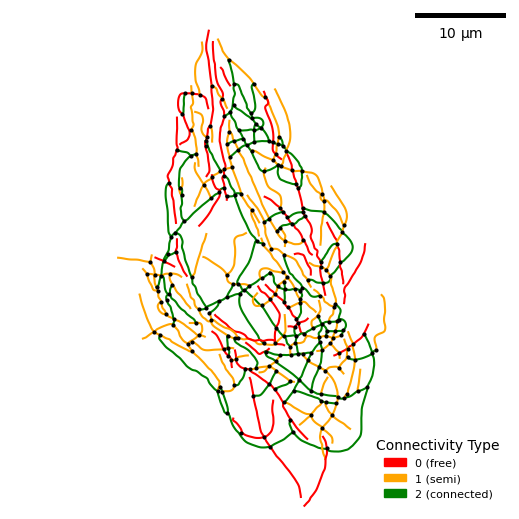

In [93]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF2D:Branch Connectivity Type',
                     nodes               = True,
                     colorbar_label      = 'type',
                     overlay             = None, 
                     scalebar            = True,
                     save                = False)




C:\Users\diogo\AppData\Local\Temp\ipykernel_10428\3313784375.py:155: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


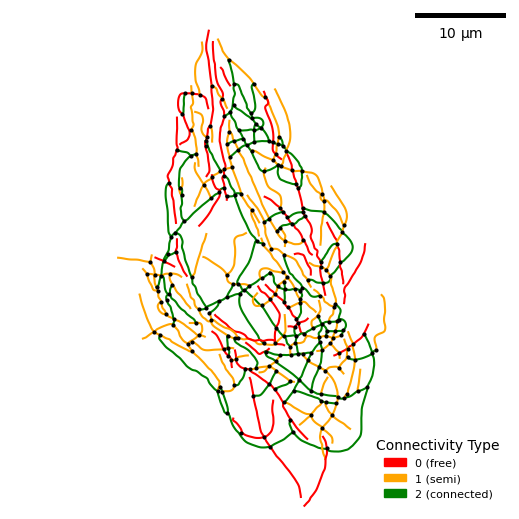

In [19]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = 'CNF2D:Branch Connectivity Type',
                     nodes               = True,
                     colorbar_label      = 'type',
                     overlay             = None, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"connectivity"))




In [93]:
import matplotlib.pyplot as plt

def plot_connection_pie(connections, save_path=None, alpha=0.5):
    import collections

    # Custom color map: 0 → red, 1 → orange, 2 → green
    color_map = {0: 'red', 1: 'orange', 2: 'green'}
    
    # Count how many filaments have 0, 1, or 2 connections
    counts = collections.Counter(connections)

    # Prepare labels and values
    raw_labels = {0: "0 (free ends)", 1: "1 (semi-connected)", 2: "2 (connected)"}
    full_data = [(raw_labels[k], counts.get(k, 0), color_map[k]) for k in [0, 1, 2] if counts.get(k, 0) > 0]

    if not full_data:
        print("No connections found.")
        return

    labels, values, base_colors = zip(*full_data)

    # Convert base colors to RGBA with alpha
    from matplotlib.colors import to_rgba
    colors = [to_rgba(c, alpha=alpha) for c in base_colors]

    # Plot
    fig, ax = plt.subplots(figsize=(5, 5))
    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )
    
    # Add black solid outline
    for wedge in wedges:
        wedge.set_edgecolor('black')
        wedge.set_linewidth(1.5)
        
    ax.set_title("Filament Connectivity Types")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', transparent=True)

    plt.show()


In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import collections
import numpy as np

def plot_connection_pie(connections, save_path=None, alpha=1.0, edge_width=2.5):
    """
    Plot a pie chart with only colored edges (no fill), and central separation.
    """
    # Custom color map: 0 → red, 1 → orange, 2 → green
    color_map = {0: 'red', 1: 'orange', 2: 'green'}
    raw_labels = {0: "0 (free ends)", 1: "1 (semi-connected)", 2: "2 (connected)"}

    # Count occurrences
    counts = collections.Counter(connections)
    full_data = [(raw_labels[k], counts.get(k, 0), color_map[k]) for k in [0, 1, 2] if counts.get(k, 0) > 0]
    print(full_data)

    if not full_data:
        print("No connections found.")
        return

    labels, values, edge_colors = zip(*full_data)

    # Explode to visually separate slices
    explode = [0.02] * len(values)

    # Dummy fill colors (transparent white)
    facecolors = [(1, 1, 1, 0) for _ in edge_colors]
    edgecolors = [to_rgba(c, alpha=alpha) for c in edge_colors]

    fig, ax = plt.subplots(figsize=(5, 5))
    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=facecolors,
        explode=explode,
        wedgeprops=dict(linewidth=edge_width)
    )

    # Apply colored edges
    for wedge, ec in zip(wedges, edgecolors):
        wedge.set_edgecolor(ec)

    ax.set_title("Filament Connectivity Types")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', transparent=True)

    plt.show()


In [9]:
26+61+57

144

[('0 (free ends)', 26, 'red'), ('1 (semi-connected)', 61, 'orange'), ('2 (connected)', 57, 'green')]


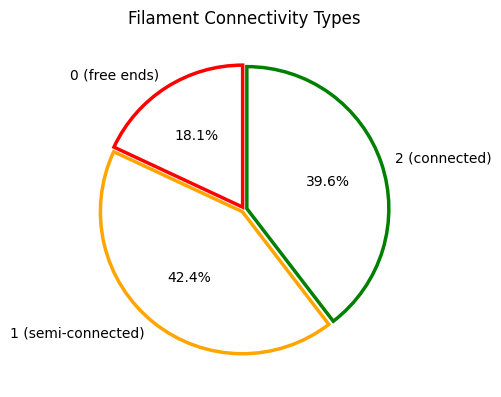

In [8]:
plot_connection_pie(ResultsDF['CNF2D:Branch Connectivity Type'].loc[0], save_path=False)

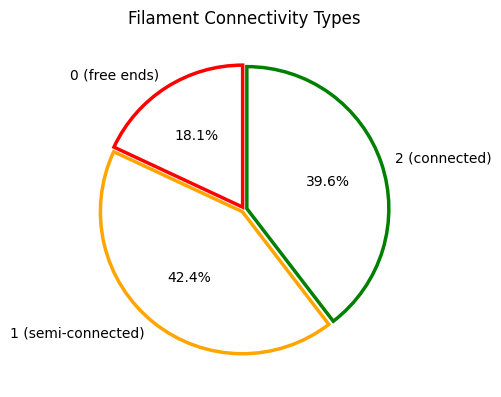

In [116]:
plot_connection_pie(ResultsDF['CNF2D:Branch Connectivity Type'].loc[0], save_path=sfolder + "\\connection_pie.pdf")

### CYTONUCL INTERACTION

ola


C:\Users\diogo\AppData\Local\Temp\ipykernel_24200\4294617022.py:164: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


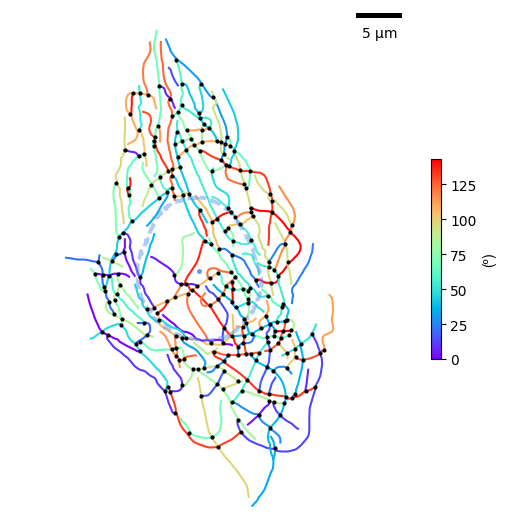

In [5]:
fig_soax = plot_soax(ResultsRow          = ResultsDF.loc[0],
                     data                = data,
                     feat                = None,
                     nodes               = True,
                     colorbar_label      = '(º)',
                     bounds              = 'default',
                     overlay             = None, 
                     scalebar            = True,
                     save                = os.path.join(sfolder,"cytonucl"))

In [10]:
ResultsDF['CYTONUCL:Area Ratio']

0    0.291841
Name: CYTONUCL:Area Ratio, dtype: object

In [44]:
def plot_cyto_green_nucl_blue_clean(ResultsRow, data, nucl=True, save=None, invert=True):
    import numpy as np, matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib_scalebar.scalebar import ScaleBar
    from skimage.filters import threshold_otsu
    from scipy.ndimage import binary_opening, binary_closing, binary_fill_holes

    # colormaps: white→green, white→blue
    cmG = LinearSegmentedColormap.from_list("W2G", [(1,1,1),(0,1,0)], N=256)
    cmB = LinearSegmentedColormap.from_list("W2B", [(1,1,1),(0,0,1)], N=256)

    def _get_img(block, idx):
        try: arr = block['Image'][str(idx)].astype(float)
        except: arr = block['Image'][idx].astype(float)
        return arr

    def _robust_norm(img, mask):
        v = img[mask>0]
        if v.size == 0: return np.zeros_like(img)
        hi = np.percentile(v, 99.5)
        if hi <= 0: return np.zeros_like(img)
        out = img / hi
        return np.clip(out, 0, 1)

    idx   = ResultsRow['Img Index']
    cellM = retrieve_mask(ResultsRow['Mask'], ResultsRow['Image Size']).astype(bool)

    cyto  = _robust_norm(_get_img(data['CYTO'], idx), cellM) * cellM
    # find nucleus block key
    nucl_key = next(k for k in ('NUCL','NUCLEUS','NUC') if k in data)
    nuc_raw  = _get_img(data[nucl_key], idx)
    nuc      = _robust_norm(nuc_raw, cellM) * cellM

    # make a nucleus mask (Otsu within cell, with gentle cleanup)
    vv = nuc_raw[cellM]
    thr = threshold_otsu(vv) if vv.size else 0
    nucM = (nuc_raw >= thr) & cellM
    nucM = binary_opening(binary_closing(nucM, iterations=1), iterations=1)
    nucM = binary_fill_holes(nucM)

    # invert (your “max − intensity”)
    if invert:
        cyto_disp = 1.0 - cyto
        nuc_disp  = 1.0 - nuc
    else:
        cyto_disp = cyto
        nuc_disp  = nuc

    # intensity-weighted alpha per layer
    gammaG, gammaB = 0.5, 0.5   # optional: reduce background bleed
    nucl_alpha = 0.65           # nucleus less opaque so filaments show through

    # COLOR BY NON-INVERTED INTENSITY (do NOT use 1-cyto / 1-nuc here)
    G = cmG(cyto)[..., :3]
    B = cmB(nuc)[...,  :3]

    # ALPHA BY NON-INVERTED INTENSITY (optionally with gamma + masks)
    aG = np.clip(cyto**gammaG, 0, 1) * cellM
    aB = np.clip(nuc**gammaB,  0, 1) * nucM * nucl_alpha

    # composite on white
    out = np.ones((*cyto.shape, 3), float)
    out = out*(1 - aG[...,None]) + G*aG[...,None]
    out = out*(1 - aB[...,None]) + B*aB[...,None]


    

    # plot
    fig, ax = plt.subplots(figsize=(8,8))
    ax.imshow(out, interpolation='nearest')
    ax.axis('off')

    # overlays
    if nucl:
        if 'Nucleus Centroid' in ResultsRow:
            ax.plot(ResultsRow['Nucleus Centroid'][1], ResultsRow['Nucleus Centroid'][0],
                    '.', color='#6495ED', markersize=5, zorder=8)
        if 'Nucleus Contour' in ResultsRow:
            nc = ResultsRow['Nucleus Contour']
            ax.plot(nc[:,0], nc[:,1], '--', color='#6495ED', linewidth=2.5, alpha=0.7, zorder=11)

    x_, y_ = ResultsRow['Mask']
    ax.set_ylim([max(x_), min(x_)])
    ax.set_xlim([min(y_), max(y_)])

    scalebar = ScaleBar(ResultsRow['Resolution'][1], "um", color='k', box_alpha=0,
                        dimension='si-length', location='lower right')
    ax.add_artist(scalebar)

    fig.tight_layout(pad=0)
    if save:
        fig.savefig(f"{save}_cytoG_nuclB_clean.pdf", format='pdf', transparent=True, bbox_inches='tight')
        fig.savefig(f"{save}_cytoG_nuclB_clean.png", format='png', transparent=True, bbox_inches='tight', dpi=1200)
    return fig


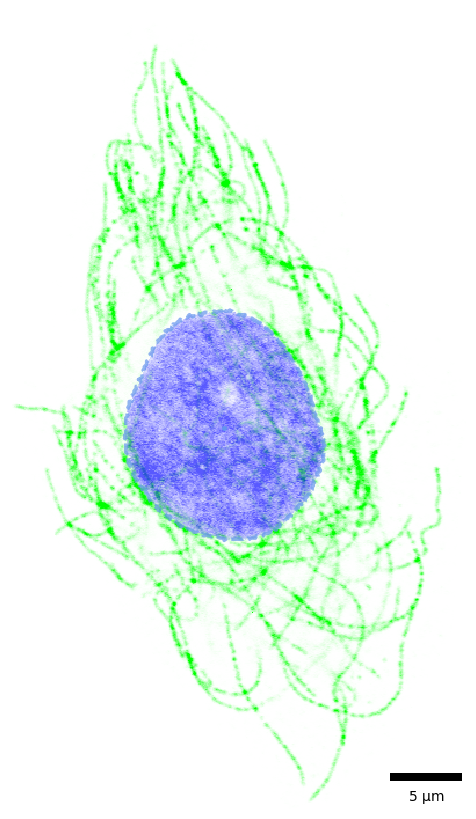

In [45]:
fig_int = plot_cyto_green_nucl_blue_clean(ResultsRow = ResultsDF.loc[cell],
                                  data       = data,
                                  nucl       = True,
                                  save       = os.path.join(sfolder,'hpacellGB'))   

### OTHER OLD THINGS

In [38]:
def plot_boxplot(ResultsRow, data, units, feat, save=False):
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    import os

    # Extract feature values
    if feat == "Pixel Intensity":
        try:
            image = data['CYTO']['Image'][str(ResultsRow['Img Index'])]
            image = image / np.max(image)
        except:
            image = data['CYTO']['Image'][ResultsRow['Img Index']]
            image = image / np.max(image)
        mask = retrieve_mask(ResultsRow['Mask'], ResultsRow['Image Size'])
        feat_list = image[mask.astype(bool)].flatten()
    else:
        feat_list = np.array(ResultsRow[feat])

    # Normalize colormap for color use
    norm = mcolors.Normalize(vmin=np.min(feat_list), vmax=np.max(feat_list))
    cmap = cm.Greys if feat == "Pixel Intensity" else cm.rainbow
    box_color = cmap(norm(np.median(feat_list)))

    # Plot
    fig_box, ax_box = plt.subplots(figsize=(3, 4))
    ax_box.boxplot(feat_list, vert=True, patch_artist=True,
                   boxprops=dict(facecolor=box_color, color='black'),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'),
                   medianprops=dict(color='black'),
                   flierprops=dict(markerfacecolor='gray', marker='o', markersize=5, linestyle='none'))

    ax_box.set_ylabel(f"{feat.split(':')[-1] if ':' in feat else feat} ({units})")
    ax_box.set_xticks([])
    ax_box.set_title("")

    if save:
        plt.savefig(str(save) + ".pdf", format='pdf', transparent=True, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

    
plot_boxplot(ResultsDF.loc[0], data, units="px", feat="CNF2D:Distance to Edge", save="distance_to_edge_box")
